# Thesis Plot Analysis

This notebook is a scaffold for the thesis-facing figures discussed in chat.

Scope:
- PtBrVId preprocessing plots
- dataset/token-length comparison
- model tradeoff plots
- training-mixture plots (Marimekko and slopegraph)
- radar chart
- confusion matrices and qualitative examples

Working style:
- keep the loading/helpers in the first cells
- implement one figure at a time
- keep one thesis-ready version and one exploratory version when a plot gets crowded
- decide early which model subset you want to compare so the notebook stays readable


In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.ticker import PercentFormatter


In [2]:
sns.set_theme(style="whitegrid", context="talk")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.titleweight"] = "bold"

REPO_ROOT = Path("..").resolve()
STATS_DIR = REPO_ROOT / "outputs" / "thesis_dataset_statistics" / "final_ptbrvarid_domains_20260423_160156"
EVAL_DIR = REPO_ROOT / "eval_results" / "encoder_decoder"
ANALYSIS_DIR = EVAL_DIR / "analysis"
FIG_DIR = REPO_ROOT / "outputs" / "thesis_plot_drafts"

CSV_PATHS = {
    "justext_removals": STATS_DIR / "justext_removals_by_domain.csv",
    "preprocessing_steps": STATS_DIR / "preprocessing_step_removals.csv",
    "token_counts": STATS_DIR / "token_counts_per_split_variant.csv",
    "stage_counts": STATS_DIR / "stage_dataset_counts.csv",
    "dataset_counts": STATS_DIR / "dataset_counts_per_split.csv",
    "golden_translation": EVAL_DIR / "bleu_copy_wer_scores_report_golden_collection.csv",
    "frmt_translation": EVAL_DIR / "bleu_copy_wer_scores_report_frmt.csv",
    "golden_classification": EVAL_DIR / "classification_scores_report_golden_collection.csv",
}

pd.DataFrame(
    {
        "name": list(CSV_PATHS.keys()),
        "path": [str(p.relative_to(REPO_ROOT)) for p in CSV_PATHS.values()],
        "exists": [p.exists() for p in CSV_PATHS.values()],
    }
)


,name,path,exists
0,justext_removals,outputs/thesis_dataset_statistics/final_ptbrva...,True
1,preprocessing_steps,outputs/thesis_dataset_statistics/final_ptbrva...,True
2,token_counts,outputs/thesis_dataset_statistics/final_ptbrva...,True
3,stage_counts,outputs/thesis_dataset_statistics/final_ptbrva...,True
4,dataset_counts,outputs/thesis_dataset_statistics/final_ptbrva...,True
5,golden_translation,eval_results/encoder_decoder/bleu_copy_wer_sco...,True
6,frmt_translation,eval_results/encoder_decoder/bleu_copy_wer_sco...,True
7,golden_classification,eval_results/encoder_decoder/classification_sc...,True


In [3]:
dfs = {name: pd.read_csv(path) for name, path in CSV_PATHS.items()}

display({name: df.shape for name, df in dfs.items()})
display(dfs["justext_removals"].head())
display(dfs["golden_translation"].head(3))


{'justext_removals': (6, 8),
 'preprocessing_steps': (42, 7),
 'token_counts': (22, 10),
 'stage_counts': (81, 8),
 'dataset_counts': (12, 10),
 'golden_translation': (26, 11),
 'frmt_translation': (18, 11),
 'golden_classification': (9, 6)}

,dataset,domain,split,raw_rows,after_jusText_rows,jusText_removed_rows,final_retained_rows,source_db
0,PtBrVId,journalistic,train,1842804,1717167,125637,1573133,data/duckdb/subs_ptbr_filtered.duckdb
1,PtBrVId,legal,train,4302002,2110995,2191007,1118531,data/duckdb/subs_ptbr_filtered.duckdb
2,PtBrVId,literature,train,81984,59513,22471,39399,data/duckdb/subs_ptbr_filtered.duckdb
3,PtBrVId,politics,train,34604,32427,2177,22828,data/duckdb/subs_ptbr_filtered.duckdb
4,PtBrVId,social_media,train,2678579,266648,2411931,219376,data/duckdb/subs_ptbr_filtered.duckdb


,model,eval_set,bleu,model_vs_copy_score_0_100,sentence_model_beats_copy_rate_score_gt_50,wer,copy_baseline_wer,model_vs_copy_wer_score_0_100,sentence_model_beats_copy_rate_wer,sentence_copy_better_or_equal_rate_wer,predictions_path
0,4B Two-Staged LoRA r24 - Golden Collection,golden_collection,75.53,45.86,0.388,0.181750,0.075729,29.411765,0.394,0.904,eval_results/encoder_decoder/compare_staged/st...
1,4B Two-Staged LoRA r24 - Golden Collection (GP...,golden_collection,77.77,46.59,0.439,0.163972,0.075729,31.593099,0.443,0.883,eval_results/encoder_decoder/compare_staged/gp...
2,4B Two-Staged LoRA r24 - Golden Collection (2n...,golden_collection,76.61,46.21,0.422,0.163919,0.075729,31.600179,0.432,0.876,eval_results/encoder_decoder/compare_staged/gp...


In [4]:
def style_ax(ax, title=None, xlabel=None, ylabel=None):
    if title:
        ax.set_title(title)
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    return ax


def minmax_scale(series, higher_is_better=True):
    values = series.astype(float)
    if not higher_is_better:
        values = -values
    spread = values.max() - values.min()
    if spread == 0:
        return pd.Series(1.0, index=series.index)
    return (values - values.min()) / spread


def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def prepare_stage_mix(df, stage_entries, split="train"):
    subset = df[df["stage_entry"].isin(stage_entries) & df["split"].eq(split)].copy()
    subset["total_rows"] = subset.groupby("stage_entry")["rows"].transform("sum")
    subset["share"] = subset["rows"] / subset["total_rows"]
    return subset.sort_values(["stage_entry", "dataset"])


def confusion_dict_to_df(confusion_dict, labels=("pt-br", "pt-pt")):
    return pd.DataFrame(
        [[confusion_dict.get(f"{src}->{dst}", 0) for dst in labels] for src in labels],
        index=labels,
        columns=labels,
    )


## Figure Roadmap

Recommended order:
1. PtBrVId jusText removals by domain
2. preprocessing-step heatmap or waterfall
3. token-length comparison across datasets
4. model metric curation table
5. rank ablation small multiples
6. quality vs copy-control scatter
7. training-mixture Marimekko
8. training-mixture slopegraph
9. radar chart
10. confusion matrices and qualitative examples

Keep the final thesis versions selective. The exploratory notebook can contain more variants than the final document.


,domain,raw_rows,jusText_removed_rows,jusText_removal_rate,final_retention_rate
4,social_media,2678579,2411931,0.900452,0.081900
1,legal,4302002,2191007,0.509299,0.260002
0,journalistic,1842804,125637,0.068177,0.853663
5,web,133664,32263,0.241374,0.132631
2,literature,81984,22471,0.274090,0.480569
3,politics,34604,2177,0.062912,0.659693


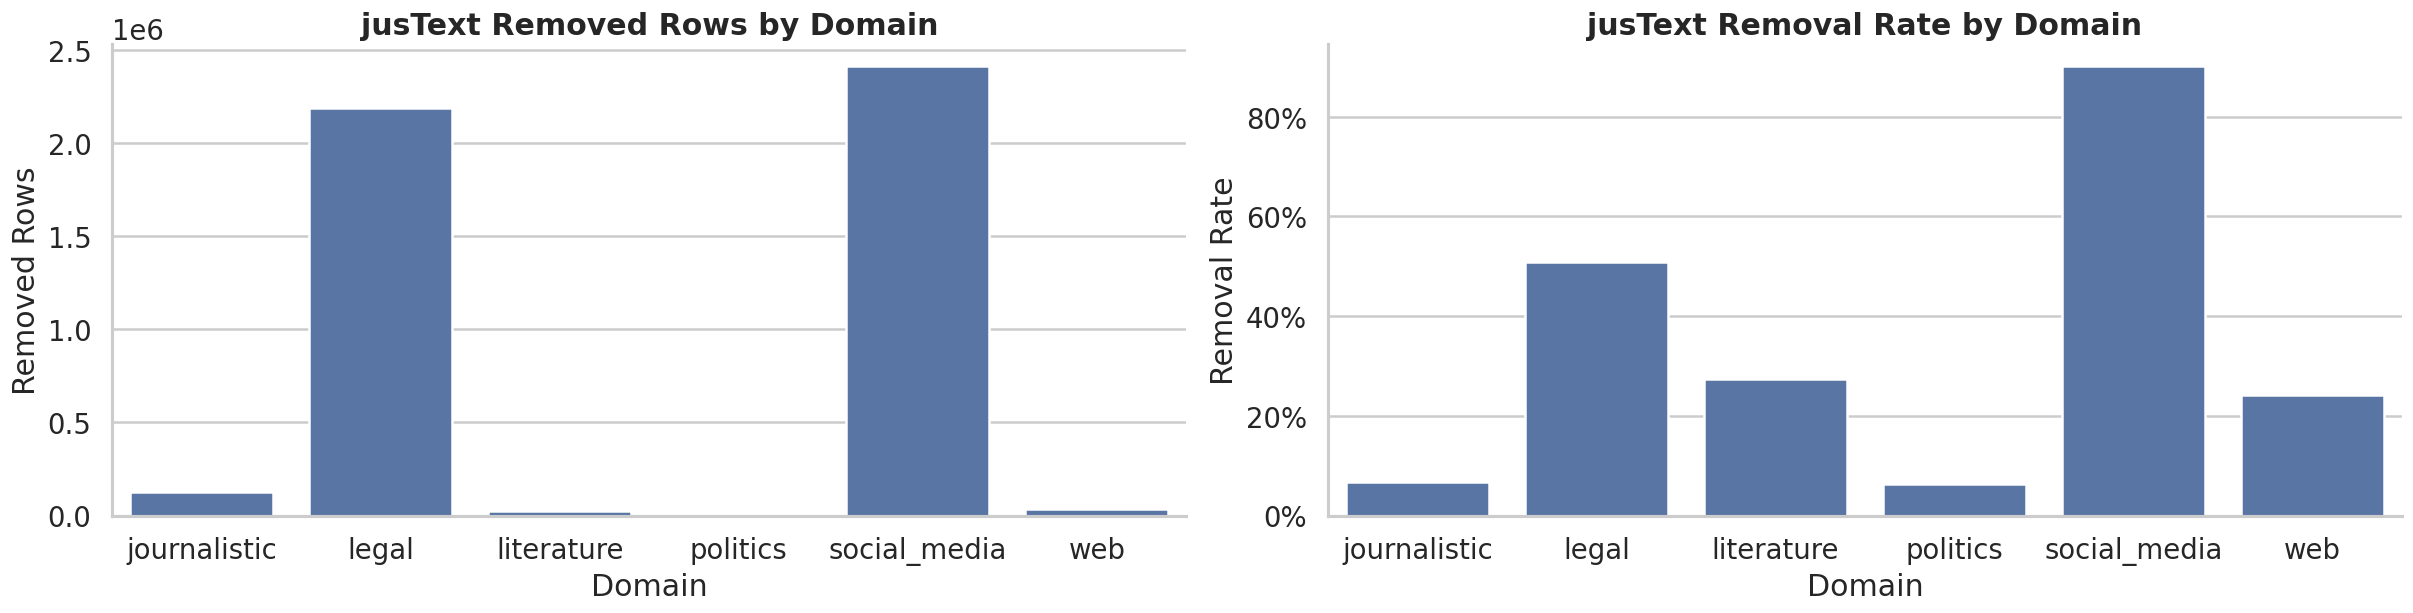

In [5]:
# 1) PtBrVId jusText removals by domain

justext_df = dfs["justext_removals"].copy()
justext_df["jusText_removal_rate"] = justext_df["jusText_removed_rows"] / justext_df["raw_rows"]
justext_df["final_retention_rate"] = justext_df["final_retained_rows"] / justext_df["raw_rows"]

display(
    justext_df[
        ["domain", "raw_rows", "jusText_removed_rows", "jusText_removal_rate", "final_retention_rate"]
    ].sort_values("jusText_removed_rows", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(20, 5), constrained_layout=True)

sns.barplot(data=justext_df, x='domain', y='jusText_removed_rows', ax=axes[0])
sns.barplot(data=justext_df, x='domain', y='jusText_removal_rate', ax=axes[1])
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[0].set_title("jusText Removed Rows by Domain")
axes[0].set_xlabel("Domain")
axes[0].set_ylabel("Removed Rows")
axes[1].set_title("jusText Removal Rate by Domain")
axes[1].set_xlabel("Domain")
axes[1].set_ylabel("Removal Rate")

plt.show()

/tmp/ipykernel_69921/3726213390.py:27: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  train_step_df.pivot_table(index="domain", columns="step_name", values="step_removal_rate")


step_name,jusText,author,clean,dedup,filters,IQR
domain,,,,,,
legal,0.5093,0.0,0.0,0.0056,0.4333,0.0598
social_media,0.9005,0.0,0.0,0.0151,0.1589,0.0069
journalistic,0.0682,0.0,0.0,0.0000,0.0640,0.0212
web,0.2414,0.0,0.0,0.0003,0.8131,0.0644
literature,0.2741,0.0,0.0,0.0000,0.3149,0.0337
politics,0.0629,0.0,0.0,0.0000,0.2468,0.0654


,removed_rows,rows_before_step,rows_after_step
step_name,,,
empty,0,9073637,9073637
jusText,4785486,9073637,4288151
author,3,4288151,4288148
clean,0,4288148,4288148
dedup,15942,4288148,4272206
filters,1170301,4272206,3101905
IQR,110910,3101905,2990995


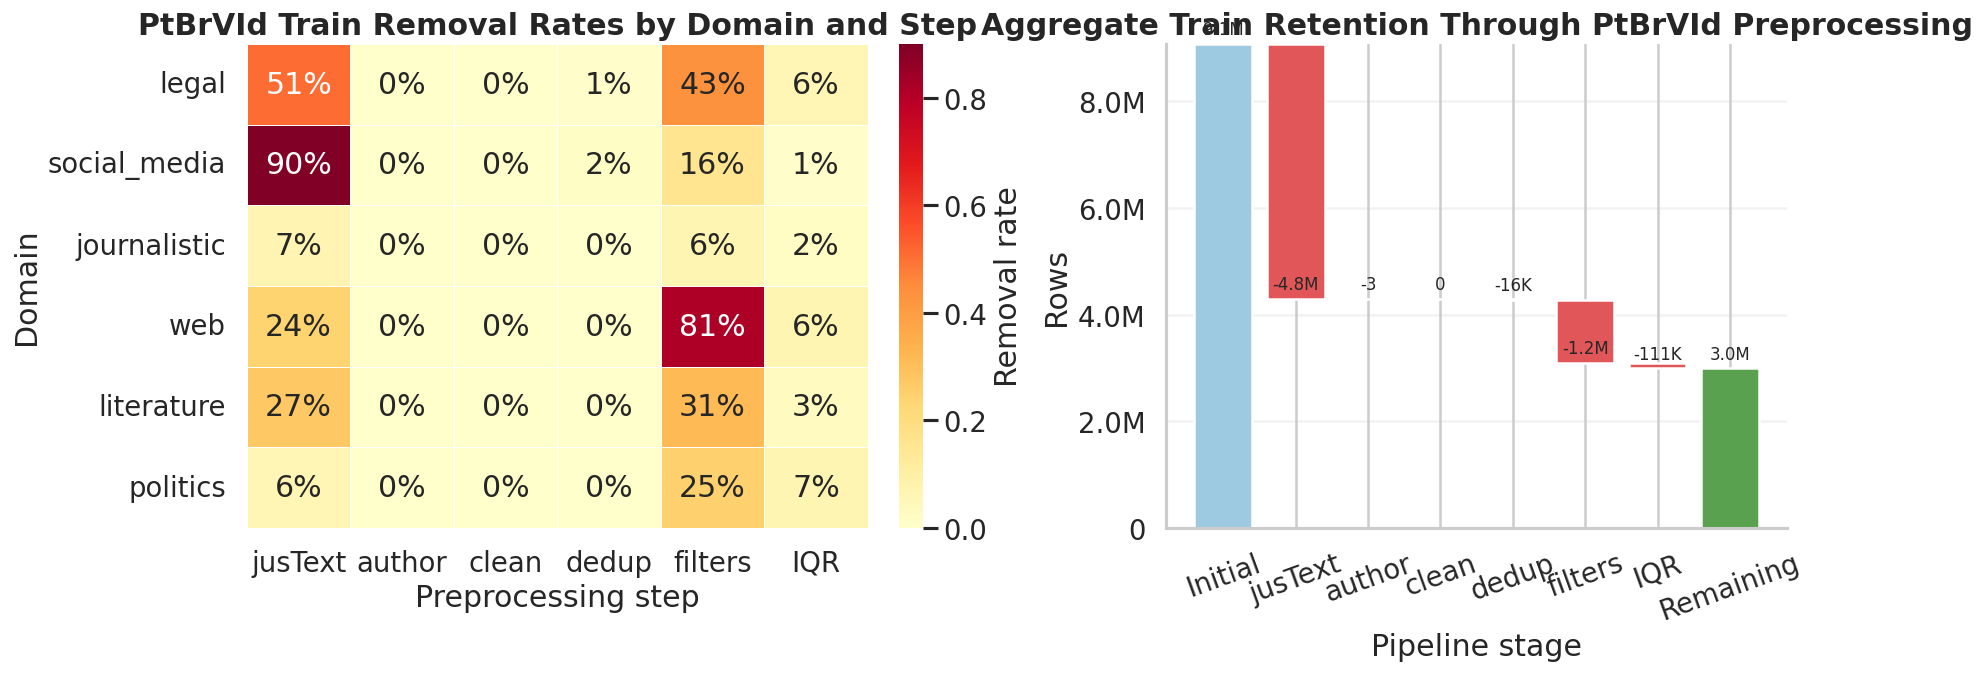

In [6]:
# 2) Preprocessing-step removals: heatmap and aggregate waterfall

from matplotlib.ticker import FuncFormatter

step_df = dfs["preprocessing_steps"].copy()
step_df["removed_rows"] = pd.to_numeric(step_df["removed_rows"])
step_df["rows_after_step"] = pd.to_numeric(step_df["rows_after_step"])
step_df["rows_before_step"] = step_df["removed_rows"] + step_df["rows_after_step"]
step_df["step_removal_rate"] = np.where(
    step_df["rows_before_step"] > 0,
    step_df["removed_rows"] / step_df["rows_before_step"],
    0.0,
)

train_step_df = step_df[step_df["split"].eq("train")].copy()
step_order = ["empty", "jusText", "author", "clean", "dedup", "filters", "IQR"]
heatmap_steps = [step for step in step_order if step != "empty"]
train_step_df["step_name"] = pd.Categorical(train_step_df["step_name"], categories=step_order, ordered=True)

domain_order = (
    train_step_df.loc[train_step_df["step_name"].eq("empty"), ["domain", "rows_before_step"]]
    .sort_values("rows_before_step", ascending=False)["domain"]
    .tolist()
)

heatmap_df = (
    train_step_df.pivot_table(index="domain", columns="step_name", values="step_removal_rate")
    .reindex(index=domain_order, columns=heatmap_steps)
)

step_summary = (
    train_step_df.groupby("step_name", observed=False)
    .agg(removed_rows=("removed_rows", "sum"), rows_before_step=("rows_before_step", "sum"), rows_after_step=("rows_after_step", "sum"))
    .reindex(step_order)
)

start_total = int(step_summary.loc["empty", "rows_before_step"])
waterfall_steps = [step for step in step_order if step != "empty"]
remaining_after_each_step = []
current_total = start_total
for step_name in waterfall_steps:
    current_total -= int(step_summary.loc[step_name, "removed_rows"])
    remaining_after_each_step.append(current_total)


def fmt_rows(value, _pos=None):
    value = float(value)
    if abs(value) >= 1_000_000:
        return f"{value / 1_000_000:.1f}M"
    if abs(value) >= 1_000:
        return f"{value / 1_000:.0f}K"
    return f"{value:.0f}"


display(heatmap_df.round(4))
display(step_summary[["removed_rows", "rows_before_step", "rows_after_step"]])

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".0%",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Removal rate"},
    ax=axes[0],
)
style_ax(
    axes[0],
    title="PtBrVId Train Removal Rates by Domain and Step",
    xlabel="Preprocessing step",
    ylabel="Domain",
)

axes[1].bar("Initial", start_total, color="#9ecae1", edgecolor="white")
current_total = start_total
for step_name in waterfall_steps:
    removed = int(step_summary.loc[step_name, "removed_rows"])
    axes[1].bar(
        step_name,
        -removed,
        bottom=current_total,
        color="#e15759",
        edgecolor="white",
    )
    current_total -= removed
axes[1].bar("Remaining", current_total, color="#59a14f", edgecolor="white")
axes[1].axhline(0, color="0.6", linewidth=1)
axes[1].yaxis.set_major_formatter(FuncFormatter(fmt_rows))
style_ax(
    axes[1],
    title="Aggregate Train Retention Through PtBrVId Preprocessing",
    xlabel="Pipeline stage",
    ylabel="Rows",
)
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(axis="y", alpha=0.25)

for idx, step_name in enumerate(["Initial"] + waterfall_steps + ["Remaining"]):
    if step_name == "Initial":
        value = start_total
        y = value
    elif step_name == "Remaining":
        value = current_total
        y = value
    else:
        removed = int(step_summary.loc[step_name, "removed_rows"])
        value = -removed
        before = start_total - int(step_summary.loc[waterfall_steps[: waterfall_steps.index(step_name)], "removed_rows"].sum())
        y = before - removed
    axes[1].text(idx, y + (start_total * 0.012), fmt_rows(value), ha="center", va="bottom", fontsize=10)

plt.show()


,variant,pt-BR,pt-PT
dataset,unit,,
OpenSubs,pair_text,10.93,11.23
GPT-Wikipedia,pair_text,26.90,27.17
FRMT,pair_text,37.96,39.31
PtBrVId-Raw,variant_text,113.62,125.58
PtBrVId-TranslatedStageB,pair_text,159.04,159.84


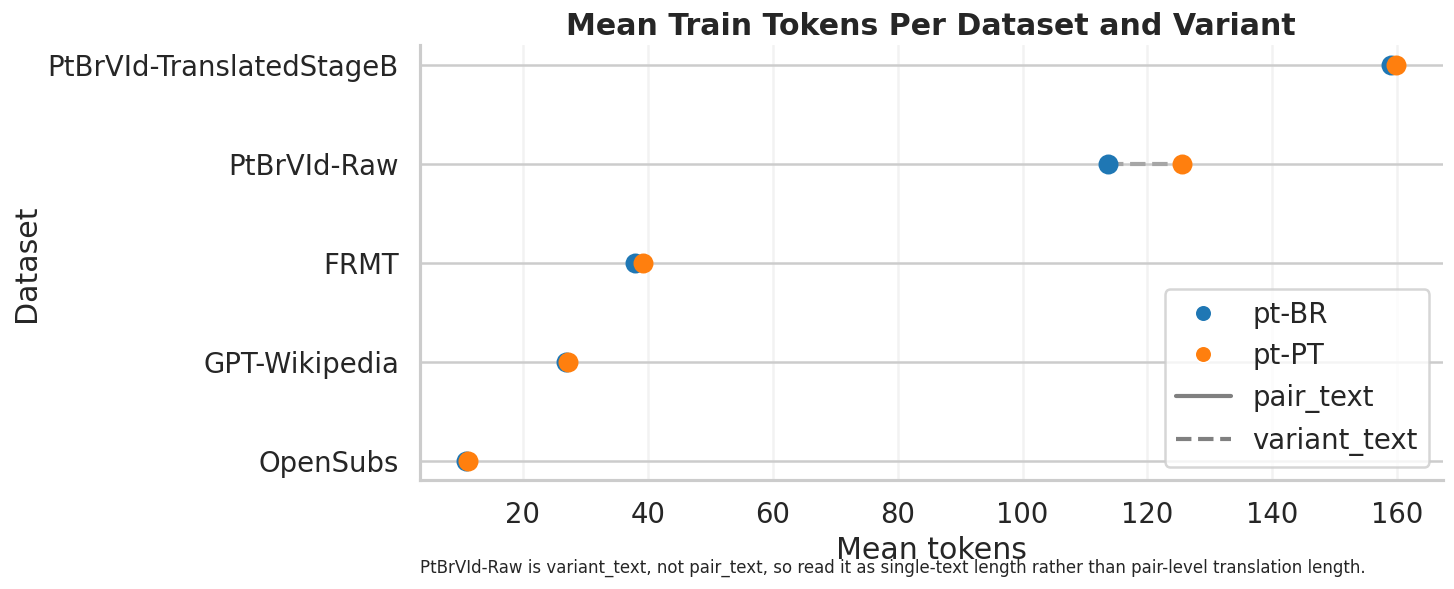

In [7]:
# 3) Dataset length comparison

tokens_df = dfs["token_counts"].copy()
train_tokens = tokens_df[tokens_df["split"].eq("train")].copy()

plot_tokens = train_tokens[["dataset", "variant", "mean_tokens", "unit"]].copy()
dataset_order = (
    plot_tokens.groupby("dataset")["mean_tokens"]
    .mean()
    .sort_values()
    .index
    .tolist()
)
plot_tokens["dataset"] = pd.Categorical(
    plot_tokens["dataset"], categories=dataset_order, ordered=True
)
plot_tokens = plot_tokens.sort_values(["dataset", "variant"])

display(
    plot_tokens.pivot(index=["dataset", "unit"], columns="variant", values="mean_tokens").round(2)
)

variant_colors = {"pt-BR": "#1f77b4", "pt-PT": "#ff7f0e"}
unit_styles = {"pair_text": "solid", "variant_text": "dashed"}

fig, ax = plt.subplots(figsize=(11, 5.5))
fig.subplots_adjust(bottom=0.22)

for y, dataset in enumerate(dataset_order):
    part = plot_tokens[plot_tokens["dataset"].eq(dataset)].set_index("variant")
    unit = part["unit"].iloc[0]

    x_br = part.loc["pt-BR", "mean_tokens"] if "pt-BR" in part.index else np.nan
    x_pt = part.loc["pt-PT", "mean_tokens"] if "pt-PT" in part.index else np.nan

    if pd.notna(x_br) and pd.notna(x_pt):
        ax.plot(
            [x_br, x_pt],
            [y, y],
            color="0.65",
            linestyle=unit_styles.get(unit, "solid"),
            linewidth=2.5,
            zorder=1,
        )

    if pd.notna(x_br):
        ax.scatter(x_br, y, s=110, color=variant_colors["pt-BR"], zorder=2)
    if pd.notna(x_pt):
        ax.scatter(x_pt, y, s=110, color=variant_colors["pt-PT"], zorder=2)

ax.set_yticks(np.arange(len(dataset_order)), dataset_order)
style_ax(ax, title="Mean Train Tokens Per Dataset and Variant", xlabel="Mean tokens", ylabel="Dataset")
ax.grid(axis="x", alpha=0.25)

legend_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=variant_colors["pt-BR"], markersize=10, label="pt-BR"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=variant_colors["pt-PT"], markersize=10, label="pt-PT"),
    Line2D([0], [0], color="0.5", linewidth=2.5, linestyle="solid", label="pair_text"),
    Line2D([0], [0], color="0.5", linewidth=2.5, linestyle="dashed", label="variant_text"),
]
ax.legend(handles=legend_handles, loc="lower right", frameon=True)

ax.text(
    0,
    -0.18,
    "PtBrVId-Raw is variant_text, not pair_text, so read it as single-text length rather than pair-level translation length.",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10,
)

plt.show()


In [8]:
# # 3b) Additional token-diversity stats

# # Preferred path: once the Slurm stats CSV includes `unique_tokenizer_ids`, use it directly.
# # Fallback path: if that column is missing, compute lowercased surface-token diversity here.

# if {"unique_tokenizer_ids", "tokenizer_type_token_ratio"}.issubset(train_tokens.columns):
#     token_summary_train = train_tokens[
#         [
#             "dataset",
#             "variant",
#             "unit",
#             "rows",
#             "total_tokens",
#             "mean_tokens",
#             "unique_tokenizer_ids",
#             "tokenizer_type_token_ratio",
#             "source_path",
#         ]
#     ].copy()
#     token_summary_train["rows"] = token_summary_train["rows"].astype(int)
#     token_summary_train["total_tokens"] = token_summary_train["total_tokens"].astype(int)
#     token_summary_train["mean_tokens"] = token_summary_train["mean_tokens"].astype(float)
#     token_summary_train["unique_tokenizer_ids"] = token_summary_train["unique_tokenizer_ids"].astype(int)
#     token_summary_train["tokenizer_type_token_ratio"] = token_summary_train["tokenizer_type_token_ratio"].astype(float)

#     display(
#         token_summary_train[
#             [
#                 "dataset",
#                 "variant",
#                 "unit",
#                 "rows",
#                 "total_tokens",
#                 "mean_tokens",
#                 "unique_tokenizer_ids",
#                 "tokenizer_type_token_ratio",
#             ]
#         ].sort_values(["dataset", "variant"])
#     )

#     fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)

#     sns.barplot(
#         data=token_summary_train,
#         x="dataset",
#         y="total_tokens",
#         hue="variant",
#         order=dataset_order,
#         hue_order=["pt-BR", "pt-PT"],
#         ax=axes[0],
#     )
#     axes[0].set_yscale("log")
#     style_ax(
#         axes[0],
#         title="Total Train Tokens From Slurm Summary",
#         xlabel="Dataset",
#         ylabel="Total tokenizer tokens (log scale)",
#     )
#     axes[0].tick_params(axis="x", rotation=20)

#     sns.barplot(
#         data=token_summary_train,
#         x="dataset",
#         y="unique_tokenizer_ids",
#         hue="variant",
#         order=dataset_order,
#         hue_order=["pt-BR", "pt-PT"],
#         ax=axes[1],
#     )
#     axes[1].set_yscale("log")
#     style_ax(
#         axes[1],
#         title="Unique Tokenizer IDs From Slurm Summary",
#         xlabel="Dataset",
#         ylabel="Unique tokenizer ids (log scale)",
#     )
#     axes[1].tick_params(axis="x", rotation=20)

#     if axes[0].legend_ is not None:
#         axes[0].legend_.remove()
#     handles, labels = axes[1].get_legend_handles_labels()
#     axes[1].legend(handles, labels, loc="upper right", frameon=True)

#     axes[1].text(
#         0,
#         -0.24,
#         "Both panels now come from the same tokenizer-based Slurm summary, so these counts are directly comparable.",
#         transform=axes[1].transAxes,
#         ha="left",
#         va="top",
#         fontsize=10,
#     )

#     plt.show()
# else:
#     import re
#     import duckdb

#     SURFACE_TOKEN_RE = re.compile(r"\w+|[^\w\s]", flags=re.UNICODE)
#     DISTINCT_TOKEN_ROW_LIMITS = {
#         # Optional per-dataset row caps for faster exploratory runs.
#         # Example: "OpenSubs": 1_000_000,
#     }
#     SUBS_PROJECT_ATTACHES = {"src": REPO_ROOT / "data" / "duckdb" / "subs.duckdb"}

#     token_summary_train = train_tokens[
#         ["dataset", "variant", "unit", "rows", "total_tokens", "mean_tokens", "source_path"]
#     ].copy()
#     token_summary_train["rows"] = token_summary_train["rows"].astype(int)
#     token_summary_train["total_tokens"] = token_summary_train["total_tokens"].astype(int)
#     token_summary_train["mean_tokens"] = token_summary_train["mean_tokens"].astype(float)

#     def resolve_token_source_path(source_path):
#         raw_path = source_path.split("::", 1)[0]
#         path = REPO_ROOT / raw_path
#         if path.exists():
#             return path

#         name = Path(raw_path).name
#         if "stageB_gpt_wiki" in raw_path and name.startswith("pairs_"):
#             fallback = REPO_ROOT / "data" / "encoder_decoder" / "t5gemma2" / name
#             if fallback.exists():
#                 return fallback

#         return path

#     def pick_jsonl_text(record, variant):
#         variant_keys = {
#             "pt-BR": ["text_pt_br", "pt_br", "text_br", "sent_pt_br"],
#             "pt-PT": ["text_pt_pt", "pt_pt", "text_pt", "sent_pt_pt", "ref_pt_pt_manual"],
#         }
#         for key in variant_keys.get(variant, []):
#             value = record.get(key)
#             if value is not None and str(value).strip():
#                 return str(value)
#         return None

#     def parse_duckdb_source(row):
#         db_rel, spec = row["source_path"].split("::", 1)
#         db_path = REPO_ROOT / db_rel

#         if "[" in spec and spec.endswith("]"):
#             base, raw_filters = spec[:-1].split("[", 1)
#         else:
#             base, raw_filters = spec, None

#         if "." in base:
#             relation, column = base.rsplit(".", 1)
#         else:
#             relation = base
#             column = "text_pt_br" if row["variant"] == "pt-BR" else "text_pt_pt"

#         clauses = []
#         params = []

#         if relation == "ptbrvarid" and row["dataset"] == "PtBrVId-Raw":
#             clauses.append("dataset = ?")
#             params.append("PtBrVId-Raw")

#         if raw_filters:
#             for part in [p.strip() for p in raw_filters.split(",") if p.strip()]:
#                 if "=" in part:
#                     key, value = part.split("=", 1)
#                 else:
#                     key, value = "split", part
#                 clauses.append(f"{key.strip()} = ?")
#                 params.append(value.strip())

#         where_sql = f" WHERE {' AND '.join(clauses)}" if clauses else ""
#         query = f"SELECT {column} AS text_value FROM {relation}{where_sql}"
#         return db_path, query, params

#     def iter_texts_from_token_row(row, limit_rows=None, batch_size=50_000):
#         source_path = row["source_path"]

#         if "::" in source_path:
#             db_path, query, params = parse_duckdb_source(row)
#             if not db_path.exists():
#                 raise FileNotFoundError(db_path)

#             con = duckdb.connect(str(db_path), read_only=True)
#             try:
#                 if db_path.name == "subs_project.duckdb":
#                     for alias, attach_path in SUBS_PROJECT_ATTACHES.items():
#                         if attach_path.exists():
#                             con.execute(f"ATTACH '{attach_path.as_posix()}' AS {alias}")
#                 cur = con.execute(query, params)
#                 seen = 0
#                 while True:
#                     rows = cur.fetchmany(batch_size)
#                     if not rows:
#                         break
#                     for (text_value,) in rows:
#                         if text_value is None:
#                             continue
#                         text_value = str(text_value).strip()
#                         if not text_value:
#                             continue
#                         yield text_value
#                         seen += 1
#                         if limit_rows is not None and seen >= limit_rows:
#                             return
#             finally:
#                 con.close()
#             return

#         file_path = resolve_token_source_path(source_path)
#         if not file_path.exists():
#             raise FileNotFoundError(file_path)

#         seen = 0
#         with open(file_path, "r", encoding="utf-8") as f:
#             for line in f:
#                 record = json.loads(line)
#                 text_value = pick_jsonl_text(record, row["variant"])
#                 if text_value is None:
#                     continue
#                 yield text_value
#                 seen += 1
#                 if limit_rows is not None and seen >= limit_rows:
#                     return

#     def distinct_surface_token_stats(row, limit_rows=None, lowercase=True):
#         unique_tokens = set()
#         total_surface_tokens = 0
#         rows_scanned = 0

#         for text in iter_texts_from_token_row(row, limit_rows=limit_rows):
#             tokens = SURFACE_TOKEN_RE.findall(text)
#             if lowercase:
#                 tokens = [tok.lower() for tok in tokens]
#             unique_tokens.update(tokens)
#             total_surface_tokens += len(tokens)
#             rows_scanned += 1

#         distinct_count = len(unique_tokens)
#         return {
#             "surface_rows_scanned": rows_scanned,
#             "surface_rows_complete": limit_rows is None,
#             "distinct_surface_tokens": distinct_count,
#             "surface_token_total": total_surface_tokens,
#             "surface_type_token_ratio": (distinct_count / total_surface_tokens) if total_surface_tokens else np.nan,
#         }

#     distinct_rows = []
#     for _, row in token_summary_train.iterrows():
#         limit_rows = DISTINCT_TOKEN_ROW_LIMITS.get(row["dataset"])
#         print(
#             f"Counting distinct surface tokens for {row['dataset']} | {row['variant']} "
#             f"(limit_rows={limit_rows})"
#         )
#         stats = distinct_surface_token_stats(row, limit_rows=limit_rows)
#         distinct_rows.append(
#             {
#                 "dataset": row["dataset"],
#                 "variant": row["variant"],
#                 "distinct_surface_tokens": stats["distinct_surface_tokens"],
#                 "surface_token_total": stats["surface_token_total"],
#                 "surface_type_token_ratio": stats["surface_type_token_ratio"],
#                 "surface_rows_scanned": stats["surface_rows_scanned"],
#                 "surface_rows_complete": stats["surface_rows_complete"],
#             }
#         )

#     distinct_token_df = pd.DataFrame(distinct_rows)

#     token_summary_train = token_summary_train.merge(
#         distinct_token_df,
#         on=["dataset", "variant"],
#         how="left",
#     )

#     display(
#         token_summary_train[
#             [
#                 "dataset",
#                 "variant",
#                 "unit",
#                 "rows",
#                 "total_tokens",
#                 "mean_tokens",
#                 "distinct_surface_tokens",
#                 "surface_type_token_ratio",
#                 "surface_rows_complete",
#             ]
#         ].sort_values(["dataset", "variant"])
#     )

#     fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)

#     sns.barplot(
#         data=token_summary_train,
#         x="dataset",
#         y="total_tokens",
#         hue="variant",
#         order=dataset_order,
#         hue_order=["pt-BR", "pt-PT"],
#         ax=axes[0],
#     )
#     axes[0].set_yscale("log")
#     style_ax(
#         axes[0],
#         title="Total Train Tokens From Slurm Summary",
#         xlabel="Dataset",
#         ylabel="Total tokenizer tokens (log scale)",
#     )
#     axes[0].tick_params(axis="x", rotation=20)

#     sns.barplot(
#         data=token_summary_train,
#         x="dataset",
#         y="distinct_surface_tokens",
#         hue="variant",
#         order=dataset_order,
#         hue_order=["pt-BR", "pt-PT"],
#         ax=axes[1],
#     )
#     axes[1].set_yscale("log")
#     style_ax(
#         axes[1],
#         title="Distinct Surface Tokens Added In Notebook",
#         xlabel="Dataset",
#         ylabel="Distinct lowercased surface tokens (log scale)",
#     )
#     axes[1].tick_params(axis="x", rotation=20)

#     if axes[0].legend_ is not None:
#         axes[0].legend_.remove()
#     handles, labels = axes[1].get_legend_handles_labels()
#     axes[1].legend(handles, labels, loc="upper right", frameon=True)

#     axes[1].text(
#         0,
#         -0.24,
#         "Left panel uses tokenizer-based totals from the Slurm summary. Right panel uses lowercased regex surface tokens, so treat it as a lexical-diversity proxy rather than a directly comparable tokenization.",
#         transform=axes[1].transAxes,
#         ha="left",
#         va="top",
#         fontsize=10,
#     )

#     plt.show()


In [9]:
# 4) Translation/classification metric tables for downstream plots

import re

gold_trans = dfs["golden_translation"].copy()
frmt_trans = dfs["frmt_translation"].copy()
gold_cls = dfs["golden_classification"].copy()
frmt_cls = pd.read_csv(EVAL_DIR / "classification_scores_report_frmt.csv")

MODEL_RENAME = {
    "4B Two-Staged LoRA r48 - Golden Collection (GPT-Wiki+FRMT Stage B label-first with cls)": "4B | 2S LoRA | r48 | GPT-Wiki+FRMT | label-first +cls",
    "4B Seq2Seq r48 - Golden Collection (GPT-Wiki+FRMT Stage B label-first first-token cls from translation eval)": "4B | Seq2Seq cls | r48 | GPT-Wiki+FRMT | label-first first-token cls",
    "270M Two-Staged Full-FT - Golden Collection (GPT-Wiki+FRMT Stage B label-first with cls equal PtBrVId Stage A)": "270M | 2S Full-FT | GPT-Wiki+FRMT | label-first +cls | equal | PtBrVId-A",
}

def parse_model_metadata(model_name):
    lower = model_name.lower()
    size_match = re.search(r"\b(270M|4B)\b", model_name)
    rank_match = re.search(r"r(?:=)?(\d+)", lower)

    if "classification head" in lower:
        family = "classification_head"
    elif "seq2seq" in lower:
        family = "seq2seq_cls"
    elif "dr. grpo" in lower:
        family = "stage_c_drgrpo"
    elif "two-staged lora" in lower:
        family = "two_staged_lora"
    elif "two-staged full-ft" in lower:
        family = "two_staged_fullft"
    elif "lora baseline" in lower:
        family = "lora_baseline"
    elif "lora" in lower:
        family = "lora"
    elif "full-ft" in lower:
        family = "fullft"
    else:
        family = "other"

    if "stage c" in lower:
        stage = "stage_c"
    elif "stage b" in lower:
        stage = "stage_b"
    else:
        stage = "baseline_or_legacy"

    if "gpt-wiki+frmt" in lower:
        recipe = "GPT-Wiki+FRMT"
    elif "gpt-wiki" in lower:
        recipe = "GPT-Wiki"
    elif "gpt+frmt" in lower:
        recipe = "GPT+FRMT"
    elif "2nd gpt refresh" in lower:
        recipe = "GPT Refresh 2"
    elif "gpt refresh" in lower:
        recipe = "GPT Refresh"
    elif "old stage b no frmt" in lower:
        recipe = "Old Stage B no FRMT"
    else:
        recipe = "baseline"

    if "label-first first-token cls" in lower:
        variant = "label-first first-token cls"
    elif "label-first translation-only" in lower:
        variant = "label-first translation-only"
    elif "label-first with cls" in lower:
        variant = "label-first +cls"
    elif "with cls" in lower:
        variant = "+cls"
    elif "bleu+wer reward" in lower:
        variant = "BLEU+WER reward"
    elif "wer reward" in lower:
        variant = "WER reward"
    else:
        variant = "standard"

    return {
        "size": size_match.group(1) if size_match else pd.NA,
        "family": family,
        "rank": int(rank_match.group(1)) if rank_match else pd.NA,
        "stage": stage,
        "recipe": recipe,
        "variant": variant,
        "ptbrvarid_stage_a": ("ptbrvid stage a" in lower) or ("ptbrvarid stage a" in lower),
        "uses_equal_rows": " equal " in lower,
    }


def make_short_label(row):
    family_short = {
        "classification_head": "Cls head",
        "seq2seq_cls": "Seq2Seq cls",
        "stage_c_drgrpo": "Stage C GRPO",
        "two_staged_lora": "2S LoRA",
        "two_staged_fullft": "2S Full-FT",
        "lora_baseline": "LoRA baseline",
        "lora": "LoRA",
        "fullft": "Full-FT",
        "other": "Other",
    }

    parts = []
    if pd.notna(row["size"]):
        parts.append(str(row["size"]))
    parts.append(family_short.get(row["family"], row["family"]))
    if pd.notna(row["rank"]):
        parts.append(f"r{int(row['rank'])}")
    if row["recipe"] != "baseline":
        parts.append(row["recipe"])
    if row["variant"] != "standard":
        parts.append(row["variant"])
    if row["uses_equal_rows"] and "equal" not in row["variant"]:
        parts.append("equal")
    if row["ptbrvarid_stage_a"]:
        parts.append("PtBrVId-A")
    return " | ".join(parts)


def enrich_report(df, task, eval_split):
    out = df.copy()
    meta = out["model"].apply(lambda model_name: pd.Series(parse_model_metadata(model_name)))
    out = pd.concat([out, meta], axis=1)
    out["task"] = task
    out["eval_split"] = eval_split
    out["short_label"] = out.apply(make_short_label, axis=1)
    out["short_label"] = out["model"].map(MODEL_RENAME).fillna(out["short_label"])
    return out

gold_trans = enrich_report(gold_trans, task="translation", eval_split="golden_collection")
frmt_trans = enrich_report(frmt_trans, task="translation", eval_split="frmt")
gold_cls = enrich_report(gold_cls, task="classification", eval_split="golden_collection")
frmt_cls = enrich_report(frmt_cls, task="classification", eval_split="frmt")

FOCUS_MODELS = sorted(
    set(
        gold_trans.loc[
            gold_trans["size"].eq("4B")
            & gold_trans["family"].isin(["two_staged_lora", "stage_c_drgrpo"])
            & gold_trans["recipe"].isin(["GPT-Wiki", "GPT-Wiki+FRMT"]),
            "short_label",
        ].tolist()
        + gold_trans.loc[
            gold_trans["size"].eq("270M")
            & gold_trans["family"].eq("two_staged_fullft")
            & gold_trans["recipe"].eq("GPT-Wiki+FRMT"),
            "short_label",
        ].tolist()
        + gold_cls.loc[gold_cls["size"].isin(["270M", "4B"]), "short_label"].tolist()
    )
)

report_cols = ["short_label", "size", "family", "rank", "recipe", "variant"]

display(pd.Series(FOCUS_MODELS, name="short_label"))

display(
    gold_trans[report_cols + ["bleu", "wer", "model_vs_copy_wer_score_0_100"]]
    .sort_values(["size", "family", "rank", "recipe", "variant"], na_position="last")
)

display(
    frmt_trans[report_cols + ["bleu", "wer", "model_vs_copy_wer_score_0_100"]]
    .sort_values(["size", "family", "rank", "recipe", "variant"], na_position="last")
)

display(
    gold_cls[report_cols + ["accuracy", "f1_macro", "n"]]
    .sort_values(["size", "family", "rank", "recipe", "variant"], na_position="last")
)

display(
    frmt_cls[report_cols + ["accuracy", "f1_macro", "n"]]
    .sort_values(["size", "family", "rank", "recipe", "variant"], na_position="last")
)

gold_trans_focus = gold_trans[gold_trans["short_label"].isin(FOCUS_MODELS)].copy()
frmt_trans_focus = frmt_trans[frmt_trans["short_label"].isin(FOCUS_MODELS)].copy()
gold_cls_focus = gold_cls[gold_cls["short_label"].isin(FOCUS_MODELS)].copy()
frmt_cls_focus = frmt_cls[frmt_cls["short_label"].isin(FOCUS_MODELS)].copy()

display(gold_trans_focus[report_cols + ["bleu", "wer"]].sort_values(["size", "family", "rank", "recipe"]))
display(frmt_trans_focus[report_cols + ["bleu", "wer"]].sort_values(["size", "family", "rank", "recipe"]))
display(gold_cls_focus[report_cols + ["accuracy", "f1_macro"]].sort_values(["size", "family", "rank", "recipe"]))
display(frmt_cls_focus[report_cols + ["accuracy", "f1_macro"]].sort_values(["size", "family", "rank", "recipe"]))


0              270M | 2S Full-FT | GPT-Wiki+FRMT | +cls
1     270M | 2S Full-FT | GPT-Wiki+FRMT | +cls | PtB...
2     270M | 2S Full-FT | GPT-Wiki+FRMT | label-firs...
3     270M | 2S Full-FT | GPT-Wiki+FRMT | label-firs...
4     270M | 2S Full-FT | GPT-Wiki+FRMT | label-firs...
5             270M | Seq2Seq cls | GPT-Wiki+FRMT | +cls
6     270M | Seq2Seq cls | GPT-Wiki+FRMT | +cls | Pt...
7     270M | Seq2Seq cls | GPT-Wiki+FRMT | label-fir...
8     270M | Seq2Seq cls | GPT-Wiki+FRMT | label-fir...
9     270M | Seq2Seq cls | GPT-Wiki+FRMT | label-fir...
10                        4B | 2S LoRA | r24 | GPT-Wiki
11                   4B | 2S LoRA | r24 | GPT-Wiki+FRMT
12                        4B | 2S LoRA | r48 | GPT-Wiki
13            4B | 2S LoRA | r48 | GPT-Wiki+FRMT | +cls
14    4B | 2S LoRA | r48 | GPT-Wiki+FRMT | label-fir...
15    4B | 2S LoRA | r48 | GPT-Wiki+FRMT | label-fir...
16                       4B | Cls head | r24 | GPT-Wiki
17        4B | Seq2Seq cls | r48 | GPT-Wiki+FRMT

,short_label,size,family,rank,recipe,variant,bleu,wer,model_vs_copy_wer_score_0_100
8,270M | Full-FT,270M,fullft,<NA>,baseline,standard,41.47,0.713465,9.595753
4,270M | 2S Full-FT | GPT Refresh,270M,two_staged_fullft,<NA>,GPT Refresh,standard,72.34,0.205435,26.934097
9,270M | 2S Full-FT | GPT Refresh 2,270M,two_staged_fullft,<NA>,GPT Refresh 2,standard,67.56,0.245072,23.606228
21,270M | 2S Full-FT | GPT-Wiki+FRMT | +cls,270M,two_staged_fullft,<NA>,GPT-Wiki+FRMT,+cls,71.46,0.211343,26.379794
23,270M | 2S Full-FT | GPT-Wiki+FRMT | +cls | PtB...,270M,two_staged_fullft,<NA>,GPT-Wiki+FRMT,+cls,54.74,0.349267,17.818779
22,270M | 2S Full-FT | GPT-Wiki+FRMT | label-firs...,270M,two_staged_fullft,<NA>,GPT-Wiki+FRMT,label-first +cls,60.55,0.306300,19.822860
24,270M | 2S Full-FT | GPT-Wiki+FRMT | label-firs...,270M,two_staged_fullft,<NA>,GPT-Wiki+FRMT,label-first +cls,49.68,0.416940,15.371198
25,270M | 2S Full-FT | GPT-Wiki+FRMT | label-firs...,270M,two_staged_fullft,<NA>,GPT-Wiki+FRMT,label-first +cls,76.15,0.142865,34.643735
3,270M | 2S Full-FT,270M,two_staged_fullft,<NA>,baseline,standard,73.06,0.194801,27.992853
7,4B | LoRA | r24 | GPT+FRMT,4B,lora,24,GPT+FRMT,standard,56.61,0.327300,18.789979


,short_label,size,family,rank,recipe,variant,bleu,wer,model_vs_copy_wer_score_0_100
1,270M | 2S Full-FT | GPT Refresh 2,270M,two_staged_fullft,<NA>,GPT Refresh 2,standard,32.68,0.559994,46.997756
13,270M | 2S Full-FT | GPT-Wiki+FRMT | +cls,270M,two_staged_fullft,<NA>,GPT-Wiki+FRMT,+cls,40.15,0.479436,50.876973
15,270M | 2S Full-FT | GPT-Wiki+FRMT | +cls | PtB...,270M,two_staged_fullft,<NA>,GPT-Wiki+FRMT,+cls,33.44,0.540933,47.861219
14,270M | 2S Full-FT | GPT-Wiki+FRMT | label-firs...,270M,two_staged_fullft,<NA>,GPT-Wiki+FRMT,label-first +cls,38.96,0.495927,50.031598
16,270M | 2S Full-FT | GPT-Wiki+FRMT | label-firs...,270M,two_staged_fullft,<NA>,GPT-Wiki+FRMT,label-first +cls,33.50,0.557769,47.096975
17,270M | 2S Full-FT | GPT-Wiki+FRMT | label-firs...,270M,two_staged_fullft,<NA>,GPT-Wiki+FRMT,label-first +cls,35.38,0.527808,48.474485
0,270M | 2S Full-FT,270M,two_staged_fullft,<NA>,baseline,standard,33.59,0.549584,47.465434
12,4B | Stage C GRPO | r24 | GPT-Wiki | BLEU+WER ...,4B,stage_c_drgrpo,24,GPT-Wiki,BLEU+WER reward,77.55,0.140064,62.145110
8,4B | Stage C GRPO | r24 | GPT-Wiki | WER reward,4B,stage_c_drgrpo,24,GPT-Wiki,WER reward,41.46,0.475581,51.078729
6,4B | Stage C GRPO | r24 | GPT-Wiki,4B,stage_c_drgrpo,24,GPT-Wiki,standard,41.31,0.476629,51.023728


,short_label,size,family,rank,recipe,variant,accuracy,f1_macro,n
4,270M | Seq2Seq cls | GPT-Wiki+FRMT | +cls,270M,seq2seq_cls,<NA>,GPT-Wiki+FRMT,+cls,0.650183,0.431714,546
7,270M | Seq2Seq cls | GPT-Wiki+FRMT | +cls | Pt...,270M,seq2seq_cls,<NA>,GPT-Wiki+FRMT,+cls,0.646520,0.428598,546
5,270M | Seq2Seq cls | GPT-Wiki+FRMT | label-fir...,270M,seq2seq_cls,<NA>,GPT-Wiki+FRMT,label-first +cls,0.648352,0.430559,546
6,270M | Seq2Seq cls | GPT-Wiki+FRMT | label-fir...,270M,seq2seq_cls,<NA>,GPT-Wiki+FRMT,label-first +cls,0.633700,0.410502,546
8,270M | Seq2Seq cls | GPT-Wiki+FRMT | label-fir...,270M,seq2seq_cls,<NA>,GPT-Wiki+FRMT,label-first +cls,0.637363,0.423469,546
0,4B | Cls head | r24 | GPT-Wiki,4B,classification_head,24,GPT-Wiki,standard,0.558862,0.526702,773
1,4B | Seq2Seq cls | r48 | GPT-Wiki+FRMT | +cls,4B,seq2seq_cls,48,GPT-Wiki+FRMT,+cls,0.695971,0.463367,546
2,4B | Seq2Seq cls | r48 | GPT-Wiki+FRMT | label...,4B,seq2seq_cls,48,GPT-Wiki+FRMT,label-first +cls,0.695971,0.462532,546
3,4B | Seq2Seq cls | r48 | GPT-Wiki+FRMT | label...,4B,seq2seq_cls,48,GPT-Wiki+FRMT,label-first first-token cls,0.706960,0.705680,546


,short_label,size,family,rank,recipe,variant,accuracy,f1_macro,n
3,270M | Seq2Seq cls | GPT-Wiki+FRMT | +cls,270M,seq2seq_cls,<NA>,GPT-Wiki+FRMT,+cls,0.780864,0.520202,5184
6,270M | Seq2Seq cls | GPT-Wiki+FRMT | +cls | Pt...,270M,seq2seq_cls,<NA>,GPT-Wiki+FRMT,+cls,0.791667,0.527499,5184
4,270M | Seq2Seq cls | GPT-Wiki+FRMT | label-fir...,270M,seq2seq_cls,<NA>,GPT-Wiki+FRMT,label-first +cls,0.768904,0.511444,5184
5,270M | Seq2Seq cls | GPT-Wiki+FRMT | label-fir...,270M,seq2seq_cls,<NA>,GPT-Wiki+FRMT,label-first +cls,0.858209,0.570200,134
7,270M | Seq2Seq cls | GPT-Wiki+FRMT | label-fir...,270M,seq2seq_cls,<NA>,GPT-Wiki+FRMT,label-first +cls,0.769869,0.512902,5184
0,4B | Seq2Seq cls | r48 | GPT-Wiki+FRMT | +cls,4B,seq2seq_cls,48,GPT-Wiki+FRMT,+cls,0.865672,0.576935,134
1,4B | Seq2Seq cls | r48 | GPT-Wiki+FRMT | label...,4B,seq2seq_cls,48,GPT-Wiki+FRMT,label-first +cls,0.895522,0.596766,134
2,4B | Seq2Seq cls | r48 | GPT-Wiki+FRMT | label...,4B,seq2seq_cls,48,GPT-Wiki+FRMT,label-first first-token cls,0.895522,0.895313,134


,short_label,size,family,rank,recipe,variant,bleu,wer
21,270M | 2S Full-FT | GPT-Wiki+FRMT | +cls,270M,two_staged_fullft,<NA>,GPT-Wiki+FRMT,+cls,71.46,0.211343
22,270M | 2S Full-FT | GPT-Wiki+FRMT | label-firs...,270M,two_staged_fullft,<NA>,GPT-Wiki+FRMT,label-first +cls,60.55,0.306300
23,270M | 2S Full-FT | GPT-Wiki+FRMT | +cls | PtB...,270M,two_staged_fullft,<NA>,GPT-Wiki+FRMT,+cls,54.74,0.349267
24,270M | 2S Full-FT | GPT-Wiki+FRMT | label-firs...,270M,two_staged_fullft,<NA>,GPT-Wiki+FRMT,label-first +cls,49.68,0.416940
25,270M | 2S Full-FT | GPT-Wiki+FRMT | label-firs...,270M,two_staged_fullft,<NA>,GPT-Wiki+FRMT,label-first +cls,76.15,0.142865
13,4B | Stage C GRPO | r24 | GPT-Wiki,4B,stage_c_drgrpo,24,GPT-Wiki,standard,87.42,0.093184
15,4B | Stage C GRPO | r24 | GPT-Wiki | WER reward,4B,stage_c_drgrpo,24,GPT-Wiki,WER reward,87.70,0.092486
20,4B | Stage C GRPO | r24 | GPT-Wiki | BLEU+WER ...,4B,stage_c_drgrpo,24,GPT-Wiki,BLEU+WER reward,87.19,0.095655
12,4B | 2S LoRA | r24 | GPT-Wiki,4B,two_staged_lora,24,GPT-Wiki,standard,87.22,0.093936
16,4B | 2S LoRA | r24 | GPT-Wiki+FRMT,4B,two_staged_lora,24,GPT-Wiki+FRMT,standard,61.32,0.297653


,short_label,size,family,rank,recipe,variant,bleu,wer
13,270M | 2S Full-FT | GPT-Wiki+FRMT | +cls,270M,two_staged_fullft,<NA>,GPT-Wiki+FRMT,+cls,40.15,0.479436
14,270M | 2S Full-FT | GPT-Wiki+FRMT | label-firs...,270M,two_staged_fullft,<NA>,GPT-Wiki+FRMT,label-first +cls,38.96,0.495927
15,270M | 2S Full-FT | GPT-Wiki+FRMT | +cls | PtB...,270M,two_staged_fullft,<NA>,GPT-Wiki+FRMT,+cls,33.44,0.540933
16,270M | 2S Full-FT | GPT-Wiki+FRMT | label-firs...,270M,two_staged_fullft,<NA>,GPT-Wiki+FRMT,label-first +cls,33.50,0.557769
17,270M | 2S Full-FT | GPT-Wiki+FRMT | label-firs...,270M,two_staged_fullft,<NA>,GPT-Wiki+FRMT,label-first +cls,35.38,0.527808
6,4B | Stage C GRPO | r24 | GPT-Wiki,4B,stage_c_drgrpo,24,GPT-Wiki,standard,41.31,0.476629
8,4B | Stage C GRPO | r24 | GPT-Wiki | WER reward,4B,stage_c_drgrpo,24,GPT-Wiki,WER reward,41.46,0.475581
12,4B | Stage C GRPO | r24 | GPT-Wiki | BLEU+WER ...,4B,stage_c_drgrpo,24,GPT-Wiki,BLEU+WER reward,77.55,0.140064
5,4B | 2S LoRA | r24 | GPT-Wiki,4B,two_staged_lora,24,GPT-Wiki,standard,41.54,0.475573
7,4B | 2S LoRA | r48 | GPT-Wiki,4B,two_staged_lora,48,GPT-Wiki,standard,41.33,0.476782


,short_label,size,family,rank,recipe,variant,accuracy,f1_macro
4,270M | Seq2Seq cls | GPT-Wiki+FRMT | +cls,270M,seq2seq_cls,<NA>,GPT-Wiki+FRMT,+cls,0.650183,0.431714
5,270M | Seq2Seq cls | GPT-Wiki+FRMT | label-fir...,270M,seq2seq_cls,<NA>,GPT-Wiki+FRMT,label-first +cls,0.648352,0.430559
6,270M | Seq2Seq cls | GPT-Wiki+FRMT | label-fir...,270M,seq2seq_cls,<NA>,GPT-Wiki+FRMT,label-first +cls,0.633700,0.410502
7,270M | Seq2Seq cls | GPT-Wiki+FRMT | +cls | Pt...,270M,seq2seq_cls,<NA>,GPT-Wiki+FRMT,+cls,0.646520,0.428598
8,270M | Seq2Seq cls | GPT-Wiki+FRMT | label-fir...,270M,seq2seq_cls,<NA>,GPT-Wiki+FRMT,label-first +cls,0.637363,0.423469
0,4B | Cls head | r24 | GPT-Wiki,4B,classification_head,24,GPT-Wiki,standard,0.558862,0.526702
1,4B | Seq2Seq cls | r48 | GPT-Wiki+FRMT | +cls,4B,seq2seq_cls,48,GPT-Wiki+FRMT,+cls,0.695971,0.463367
2,4B | Seq2Seq cls | r48 | GPT-Wiki+FRMT | label...,4B,seq2seq_cls,48,GPT-Wiki+FRMT,label-first +cls,0.695971,0.462532
3,4B | Seq2Seq cls | r48 | GPT-Wiki+FRMT | label...,4B,seq2seq_cls,48,GPT-Wiki+FRMT,label-first first-token cls,0.706960,0.705680


,short_label,size,family,rank,recipe,variant,accuracy,f1_macro
3,270M | Seq2Seq cls | GPT-Wiki+FRMT | +cls,270M,seq2seq_cls,<NA>,GPT-Wiki+FRMT,+cls,0.780864,0.520202
4,270M | Seq2Seq cls | GPT-Wiki+FRMT | label-fir...,270M,seq2seq_cls,<NA>,GPT-Wiki+FRMT,label-first +cls,0.768904,0.511444
5,270M | Seq2Seq cls | GPT-Wiki+FRMT | label-fir...,270M,seq2seq_cls,<NA>,GPT-Wiki+FRMT,label-first +cls,0.858209,0.570200
6,270M | Seq2Seq cls | GPT-Wiki+FRMT | +cls | Pt...,270M,seq2seq_cls,<NA>,GPT-Wiki+FRMT,+cls,0.791667,0.527499
7,270M | Seq2Seq cls | GPT-Wiki+FRMT | label-fir...,270M,seq2seq_cls,<NA>,GPT-Wiki+FRMT,label-first +cls,0.769869,0.512902
0,4B | Seq2Seq cls | r48 | GPT-Wiki+FRMT | +cls,4B,seq2seq_cls,48,GPT-Wiki+FRMT,+cls,0.865672,0.576935
1,4B | Seq2Seq cls | r48 | GPT-Wiki+FRMT | label...,4B,seq2seq_cls,48,GPT-Wiki+FRMT,label-first +cls,0.895522,0.596766
2,4B | Seq2Seq cls | r48 | GPT-Wiki+FRMT | label...,4B,seq2seq_cls,48,GPT-Wiki+FRMT,label-first first-token cls,0.895522,0.895313


,short_label,size,comparison_family,stage,recipe,variant,rank,gold_bleu,gold_wer,frmt_bleu,frmt_wer,gold_cls_f1_macro,frmt_cls_f1_macro,is_placeholder
0,4B | two_staged_lora | GPT-Wiki | standard,4B,two_staged_lora,stage_b,GPT-Wiki,standard,8,NaN,NaN,NaN,NaN,NaN,NaN,True
1,4B | 2S LoRA | r24 | GPT-Wiki,4B,two_staged_lora,stage_b,GPT-Wiki,standard,24,87.22,0.093936,41.54,0.475573,NaN,NaN,False
2,4B | 2S LoRA | r48 | GPT-Wiki,4B,two_staged_lora,stage_b,GPT-Wiki,standard,48,88.19,0.086149,41.33,0.476782,NaN,NaN,False


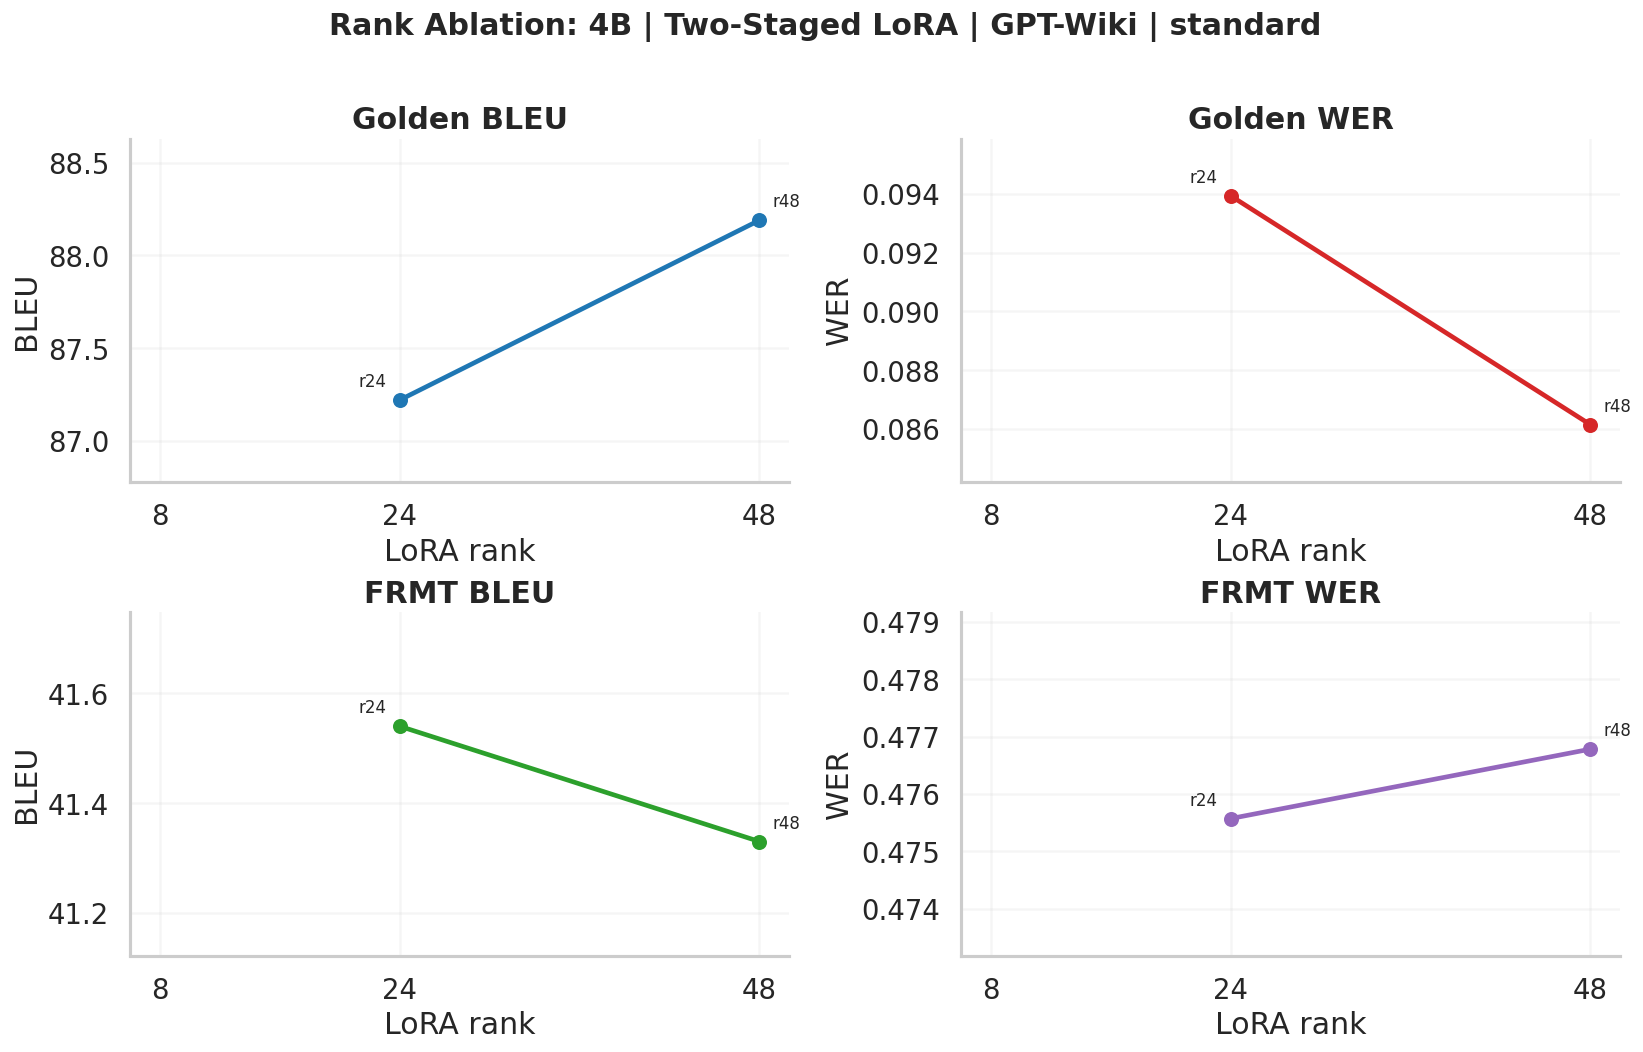

In [10]:
# 5) Rank ablation small multiples

# Keep this comparison within one family / recipe / variant at a time.
# Golden and FRMT reports label the same run differently (`Golden Collection` vs `FRMT Eval`),
# so use a normalized key rather than the raw `model` string.


def comparison_family_from_row(row):
    model_lower = str(row["model"]).lower()
    if row["family"] == "seq2seq_cls":
        if "full-ft" in model_lower or str(row.get("size", "")) == "270M":
            return "two_staged_fullft"
        return "two_staged_lora"
    return row["family"]


def add_ablation_key(df):
    out = df.copy()
    out["comparison_family"] = out.apply(comparison_family_from_row, axis=1)
    key_cols = [
        "size",
        "comparison_family",
        "rank",
        "stage",
        "recipe",
        "variant",
        "ptbrvarid_stage_a",
        "uses_equal_rows",
    ]
    out["ablation_key"] = out[key_cols].astype(str).agg(" | ".join, axis=1)
    return out


gold_trans_ab = add_ablation_key(gold_trans)
frmt_trans_ab = add_ablation_key(frmt_trans)
gold_cls_ab = add_ablation_key(gold_cls)
frmt_cls_ab = add_ablation_key(frmt_cls)

rank_df = (
    gold_trans_ab[
        [
            "ablation_key",
            "short_label",
            "model",
            "size",
            "family",
            "comparison_family",
            "rank",
            "stage",
            "recipe",
            "variant",
            "ptbrvarid_stage_a",
            "uses_equal_rows",
            "bleu",
            "wer",
            "model_vs_copy_wer_score_0_100",
        ]
    ]
    .rename(
        columns={
            "bleu": "gold_bleu",
            "wer": "gold_wer",
            "model_vs_copy_wer_score_0_100": "gold_copy_advantage_wer",
        }
    )
    .merge(
        frmt_trans_ab[["ablation_key", "bleu", "wer", "model_vs_copy_wer_score_0_100"]].rename(
            columns={
                "bleu": "frmt_bleu",
                "wer": "frmt_wer",
                "model_vs_copy_wer_score_0_100": "frmt_copy_advantage_wer",
            }
        ),
        on="ablation_key",
        how="left",
    )
    .merge(
        gold_cls_ab[["ablation_key", "f1_macro", "accuracy"]].rename(
            columns={"f1_macro": "gold_cls_f1_macro", "accuracy": "gold_cls_accuracy"}
        ),
        on="ablation_key",
        how="left",
    )
    .merge(
        frmt_cls_ab[["ablation_key", "f1_macro", "accuracy"]].rename(
            columns={"f1_macro": "frmt_cls_f1_macro", "accuracy": "frmt_cls_accuracy"}
        ),
        on="ablation_key",
        how="left",
    )
)

ABLATION_SIZE = "4B"
ABLATION_FAMILY = "two_staged_lora"
ABLATION_STAGE = "stage_b"
ABLATION_RECIPE = "GPT-Wiki"
ABLATION_VARIANT = "standard"

# Draft-only placeholder support.
EXPECTED_RANKS = [8, 24, 48]
USE_PLACEHOLDER_RANKS = True
MANUAL_PLACEHOLDER_ROWS = [
    # Example:
    # {
    #     "rank": 8,
    #     "gold_bleu": 24.0,
    #     "gold_wer": 33.0,
    #     "frmt_bleu": 10.0,
    #     "frmt_wer": 58.0,
    # },
]

ablation_df = rank_df[
    rank_df["size"].eq(ABLATION_SIZE)
    & rank_df["comparison_family"].eq(ABLATION_FAMILY)
    & rank_df["stage"].eq(ABLATION_STAGE)
    & rank_df["recipe"].eq(ABLATION_RECIPE)
    & rank_df["variant"].eq(ABLATION_VARIANT)
].copy()

ablation_df["rank"] = pd.to_numeric(ablation_df["rank"], errors="coerce")
ablation_df = ablation_df.dropna(subset=["rank"]).sort_values("rank")
ablation_df["rank"] = ablation_df["rank"].astype(int)
ablation_df["is_placeholder"] = False

metric_cols = ["gold_bleu", "gold_wer", "frmt_bleu", "frmt_wer", "gold_cls_f1_macro", "frmt_cls_f1_macro"]
manual_placeholder_by_rank = {row["rank"]: row for row in MANUAL_PLACEHOLDER_ROWS}
placeholder_rows = []

if USE_PLACEHOLDER_RANKS and EXPECTED_RANKS:
    metadata_template = {
        "short_label": f"{ABLATION_SIZE} | {ABLATION_FAMILY} | {ABLATION_RECIPE} | {ABLATION_VARIANT}",
        "model": "placeholder",
        "size": ABLATION_SIZE,
        "family": ABLATION_FAMILY,
        "comparison_family": ABLATION_FAMILY,
        "stage": ABLATION_STAGE,
        "recipe": ABLATION_RECIPE,
        "variant": ABLATION_VARIANT,
        "ptbrvarid_stage_a": False,
        "uses_equal_rows": False,
        "gold_copy_advantage_wer": np.nan,
        "frmt_copy_advantage_wer": np.nan,
        "gold_cls_accuracy": np.nan,
        "frmt_cls_accuracy": np.nan,
        "ablation_key": "placeholder",
        "is_placeholder": True,
    }
    available_ranks = set(ablation_df["rank"])
    for expected_rank in EXPECTED_RANKS:
        if expected_rank in available_ranks:
            continue
        row = metadata_template | {"rank": expected_rank}
        if expected_rank in manual_placeholder_by_rank:
            row.update(manual_placeholder_by_rank[expected_rank])
        else:
            for metric in metric_cols:
                row[metric] = np.nan
        placeholder_rows.append(row)

plot_df = pd.concat([ablation_df, pd.DataFrame(placeholder_rows)], ignore_index=True, sort=False)
plot_df = plot_df.sort_values("rank").reset_index(drop=True)

tick_ranks = EXPECTED_RANKS if EXPECTED_RANKS else sorted(plot_df["rank"].dropna().unique())

display(
    plot_df[
        [
            "short_label",
            "size",
            "comparison_family",
            "stage",
            "recipe",
            "variant",
            "rank",
            "gold_bleu",
            "gold_wer",
            "frmt_bleu",
            "frmt_wer",
            "gold_cls_f1_macro",
            "frmt_cls_f1_macro",
            "is_placeholder",
        ]
    ]
)

real_df = plot_df[~plot_df["is_placeholder"]].copy()
placeholder_df = plot_df[plot_df["is_placeholder"]].copy()
visible_placeholder_df = placeholder_df.dropna(subset=metric_cols, how="all")
show_placeholder_scaffold = not visible_placeholder_df.empty

if max(len(real_df), len(plot_df)) < 2:
    raise ValueError(
        "The current ablation filter returned fewer than two ranks. "
        "Change ABLATION_SIZE / ABLATION_FAMILY / ABLATION_STAGE / ABLATION_RECIPE / ABLATION_VARIANT."
    )

family_labels = {
    "two_staged_lora": "Two-Staged LoRA",
    "two_staged_fullft": "Two-Staged Full-FT",
    "stage_c_drgrpo": "Stage C Dr. GRPO",
}

metrics = [
    ("gold_bleu", "Golden BLEU", "BLEU", "#1f77b4"),
    ("gold_wer", "Golden WER", "WER", "#d62728"),
    ("frmt_bleu", "FRMT BLEU", "BLEU", "#2ca02c"),
    ("frmt_wer", "FRMT WER", "WER", "#9467bd"),
]

fig, axes = plt.subplots(2, 2, figsize=(13.8, 9.2), sharex=True)
fig.subplots_adjust(left=0.08, right=0.98, top=0.86, bottom=0.12, wspace=0.26, hspace=0.38)

for ax, (metric, title, ylabel, color) in zip(axes.flat, metrics):
    real_metric = real_df.dropna(subset=[metric]).copy().sort_values("rank")
    placeholder_metric = visible_placeholder_df.dropna(subset=[metric]).copy().sort_values("rank")

    if len(real_metric) >= 2:
        ax.plot(
            real_metric["rank"],
            real_metric[metric],
            color=color,
            linewidth=2.8,
            marker="o",
            markersize=8,
            zorder=3,
        )
    elif len(real_metric) == 1:
        ax.scatter(real_metric["rank"], real_metric[metric], color=color, s=95, zorder=3)

    if not placeholder_metric.empty:
        ax.scatter(
            placeholder_metric["rank"],
            placeholder_metric[metric],
            s=100,
            facecolors="none",
            edgecolors=color,
            linewidths=2.1,
            zorder=4,
        )

    rank_count = len(real_metric)
    for pos, (_, row) in enumerate(real_metric.iterrows()):
        if pos == 0:
            xytext, ha = (-8, 8), "right"
        elif pos == rank_count - 1:
            xytext, ha = (8, 8), "left"
        else:
            xytext, ha = (0, 8), "center"
        ax.annotate(
            f"r{row['rank']}",
            (row["rank"], row[metric]),
            textcoords="offset points",
            xytext=xytext,
            ha=ha,
            fontsize=10,
        )
    for _, row in placeholder_metric.iterrows():
        ax.annotate(
            f"r{row['rank']}*",
            (row["rank"], row[metric]),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            fontsize=10,
            color="0.35",
        )

    style_ax(ax, title=title, xlabel="LoRA rank", ylabel=ylabel)
    ax.set_xticks(tick_ranks)
    ax.set_xlim(min(tick_ranks) - 2, max(tick_ranks) + 2)
    ax.grid(axis="both", alpha=0.18)
    ax.tick_params(axis="x", labelbottom=True)

    metric_values = pd.concat([real_metric[metric], placeholder_metric[metric]], ignore_index=True).dropna()
    if not metric_values.empty:
        lo = metric_values.min()
        hi = metric_values.max()
        pad = max((hi - lo) * 0.25, abs(hi) * 0.005, 0.0015)
        ax.set_ylim(lo - pad, hi + pad)

family_label = family_labels.get(ABLATION_FAMILY, ABLATION_FAMILY.replace("_", " ").title())
fig.suptitle(
    f"Rank Ablation: {ABLATION_SIZE} | {family_label} | {ABLATION_RECIPE} | {ABLATION_VARIANT}",
    y=0.975,
    fontsize=18,
    fontweight="bold",
)

if show_placeholder_scaffold:
    legend_handles = [
        Line2D([0], [0], color="0.35", marker="o", linewidth=2.8, markersize=8, label="real run"),
        Line2D([0], [0], color="0.35", marker="o", markerfacecolor="none", linewidth=0, markersize=8, label="placeholder rank"),
    ]
    fig.legend(handles=legend_handles, loc="upper right", bbox_to_anchor=(0.97, 0.935), frameon=False, ncol=2)
    fig.text(
        0.5,
        0.04,
        "Hollow markers with * are placeholder ranks for draft layout only.",
        ha="center",
        va="bottom",
        fontsize=10,
        color="0.35",
    )

plt.show()


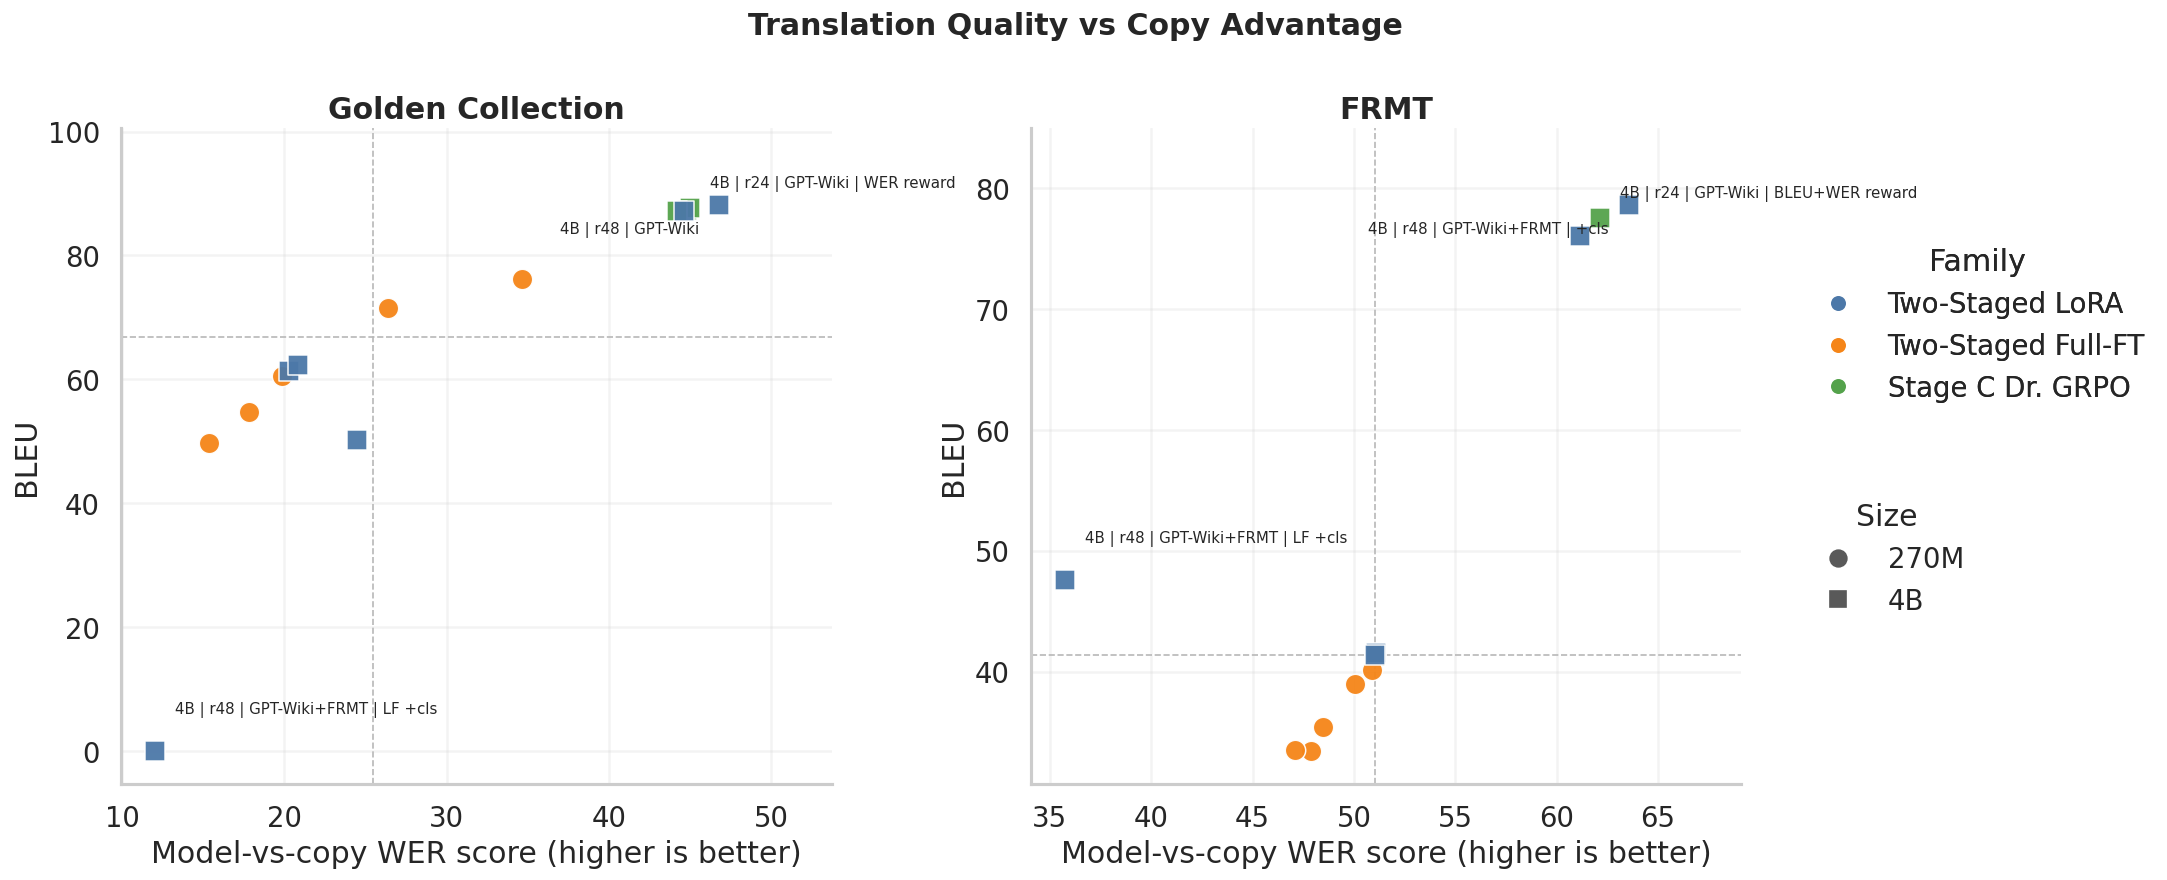

In [11]:
# 6) Quality vs copy-control scatter


def scatter_family_from_row(row):
    model_lower = str(row["model"]).lower()
    if row["family"] == "seq2seq_cls":
        if "full-ft" in model_lower or str(row.get("size", "")) == "270M":
            return "two_staged_fullft"
        return "two_staged_lora"
    return row["family"]


def compact_model_label(row):
    parts = [str(row["size"])] if pd.notna(row.get("size")) else []
    if pd.notna(row.get("rank")):
        parts.append(f"r{int(row['rank'])}")
    if row.get("recipe") not in (None, "baseline"):
        parts.append(str(row["recipe"]).replace("GPT-Wikipedia", "GPT-Wiki"))
    variant = str(row.get("variant", "standard"))
    if variant != "standard":
        variant = variant.replace("label-first", "LF")
        parts.append(variant)
    return " | ".join(parts) if parts else str(row.get("short_label", row.get("model", "model")))


def choose_scatter_labels(part):
    return (
        pd.concat(
            [
                part.nlargest(2, "y_quality"),
                part.nlargest(2, "x_copy_advantage"),
                part.nsmallest(1, "x_copy_advantage"),
            ],
            ignore_index=True,
        )
        .drop_duplicates("label_for_plot")
        .copy()
    )


def compute_outward_offsets(label_df, x_col, y_col):
    offsets = {}
    x_mid = label_df[x_col].median()
    y_mid = label_df[y_col].median()
    counters = {}

    for idx, row in label_df.sort_values([y_col, x_col], ascending=[False, True]).iterrows():
        horiz = "left" if row[x_col] <= x_mid else "right"
        vert = "low" if row[y_col] <= y_mid else "high"
        key = (horiz, vert)
        counters[key] = counters.get(key, 0) + 1
        step = counters[key] - 1

        dx = 12 + 8 * (step // 2)
        dy = 10 + 10 * (step % 2)
        dx = dx if horiz == "left" else -dx
        dy = dy if vert == "low" else -dy

        offsets[idx] = {
            "xytext": (dx, dy),
            "ha": "left" if dx > 0 else "right",
            "va": "bottom" if dy > 0 else "top",
        }
    return offsets


family_labels = {
    "two_staged_lora": "Two-Staged LoRA",
    "two_staged_fullft": "Two-Staged Full-FT",
    "stage_c_drgrpo": "Stage C Dr. GRPO",
    "lora_baseline": "LoRA baseline",
    "lora": "LoRA",
    "fullft": "Full-FT",
    "classification_head": "Classification head",
    "seq2seq_cls": "Seq2Seq cls",
}
family_palette = {
    "Two-Staged LoRA": "#4C78A8",
    "Two-Staged Full-FT": "#F58518",
    "Stage C Dr. GRPO": "#54A24B",
    "LoRA baseline": "#E45756",
    "LoRA": "#72B7B2",
    "Full-FT": "#B279A2",
    "Classification head": "#FF9DA6",
    "Seq2Seq cls": "#9D755D",
}
size_markers = {"270M": "o", "4B": "s"}

scatter_frames = []
for eval_label, report_df in [("Golden Collection", gold_trans.copy()), ("FRMT", frmt_trans.copy())]:
    part = report_df.copy()
    part["comparison_family"] = part.apply(scatter_family_from_row, axis=1)
    part["family_label"] = part["comparison_family"].map(family_labels).fillna(part["comparison_family"])
    part["x_copy_advantage"] = pd.to_numeric(part["model_vs_copy_wer_score_0_100"], errors="coerce")
    part["y_quality"] = pd.to_numeric(part["bleu"], errors="coerce")
    part["eval_label"] = eval_label
    part["label_for_plot"] = part.apply(compact_model_label, axis=1)
    scatter_frames.append(part)

scatter_df = pd.concat(scatter_frames, ignore_index=True)
scatter_df = scatter_df[scatter_df["short_label"].isin(FOCUS_MODELS)].copy()
if scatter_df.empty:
    scatter_df = pd.concat(scatter_frames, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(18.5, 7.8))
fig.subplots_adjust(left=0.07, right=0.80, top=0.84, bottom=0.14, wspace=0.28)

for ax, eval_label in zip(axes, ["Golden Collection", "FRMT"]):
    part = scatter_df[scatter_df["eval_label"].eq(eval_label)].dropna(subset=["x_copy_advantage", "y_quality"]).copy()

    for (family_label, size_label), grp in part.groupby(["family_label", "size"], dropna=False):
        marker = size_markers.get(size_label, "o")
        ax.scatter(
            grp["x_copy_advantage"],
            grp["y_quality"],
            s=150,
            marker=marker,
            color=family_palette.get(family_label, "#666666"),
            edgecolor="white",
            linewidth=0.9,
            alpha=0.95,
            zorder=3,
        )

    x_med = part["x_copy_advantage"].median()
    y_med = part["y_quality"].median()
    ax.axvline(x_med, color="0.72", linestyle="--", linewidth=1)
    ax.axhline(y_med, color="0.72", linestyle="--", linewidth=1)

    label_part = choose_scatter_labels(part)
    label_offsets = compute_outward_offsets(label_part, "x_copy_advantage", "y_quality")

    for idx, row in label_part.iterrows():
        opts = label_offsets[idx]
        ax.annotate(
            row["label_for_plot"],
            (row["x_copy_advantage"], row["y_quality"]),
            textcoords="offset points",
            xytext=opts["xytext"],
            ha=opts["ha"],
            va=opts["va"],
            fontsize=9,
            clip_on=False,
        )

    x_min, x_max = part["x_copy_advantage"].min(), part["x_copy_advantage"].max()
    y_min, y_max = part["y_quality"].min(), part["y_quality"].max()
    x_span = max(x_max - x_min, 1.0)
    y_span = max(y_max - y_min, 1.0)
    ax.set_xlim(x_min - 0.06 * x_span, x_max + 0.20 * x_span)
    ax.set_ylim(y_min - 0.06 * y_span, y_max + 0.14 * y_span)

    style_ax(
        ax,
        title=eval_label,
        xlabel="Model-vs-copy WER score (higher is better)",
        ylabel="BLEU",
    )
    ax.grid(alpha=0.22)

family_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=color, markersize=10, label=label)
    for label, color in family_palette.items()
    if label in set(scatter_df["family_label"])
]
size_handles = [
    Line2D([0], [0], marker=marker, color="0.35", linestyle="", markersize=10, label=size)
    for size, marker in size_markers.items()
    if size in set(scatter_df["size"])
]

family_legend = fig.legend(
    handles=family_handles,
    title="Family",
    loc="center left",
    bbox_to_anchor=(0.82, 0.63),
    frameon=False,
)
fig.add_artist(family_legend)
fig.legend(
    handles=size_handles,
    title="Size",
    loc="center left",
    bbox_to_anchor=(0.82, 0.38),
    frameon=False,
)
fig.suptitle("Translation Quality vs Copy Advantage", y=0.965, fontsize=18, fontweight="bold")

plt.show()


In [12]:
# 7) Training-mixture setup

stage_df = dfs["stage_counts"].copy()
stage_df["rows"] = pd.to_numeric(stage_df["rows"], errors="coerce")
stage_df["dataset_plot"] = stage_df["dataset"].replace({"GPT": "GPT-Wikipedia"})

# IMPORTANT:
# This file mixes literal export profiles and thesis_assumption profiles.
# The plots below focus on the staged families that are easiest to explain in the thesis.

stage_a_literal = [
    "stageA_opensubs_only_translation",
    "stageA_opensubs_frmt_translation",
    "stageA_opensubs_plus_ptbrvarid_with_cls_mixed",
]

stage_b_literal = [
    "stageB_gpt_wiki_translation",
    "stageB_gpt_wiki_frmt_mix_translation",
    "stageB_gpt_wiki_frmt_label_first_translation",
    "stageB_gpt_wiki_frmt_translation_plus_cls_mixed",
    "stageB_gpt_wiki_frmt_mix_optional_ptbrvarid_translation",
]

stage_label_map = {
    "stageA_opensubs_only_translation": "OpenSubs only",
    "stageA_opensubs_frmt_translation": "OpenSubs + FRMT",
    "stageA_opensubs_plus_ptbrvarid_with_cls_mixed": "OpenSubs + PtBrVId (+cls)",
    "stageB_gpt_wiki_translation": "GPT-Wiki only",
    "stageB_gpt_wiki_frmt_mix_translation": "GPT-Wiki + FRMT",
    "stageB_gpt_wiki_frmt_label_first_translation": "GPT-Wiki + FRMT LF",
    "stageB_gpt_wiki_frmt_translation_plus_cls_mixed": "GPT-Wiki + FRMT (+cls)",
    "stageB_gpt_wiki_frmt_mix_optional_ptbrvarid_translation": "GPT-Wiki + FRMT + PtBrVId",
}

stage_axis_label_map = {
    "stageA_opensubs_only_translation": "OpenSubs only",
    "stageA_opensubs_frmt_translation": "OpenSubs +\nFRMT",
    "stageA_opensubs_plus_ptbrvarid_with_cls_mixed": "OpenSubs +\nPtBrVId (+cls)",
    "stageB_gpt_wiki_translation": "GPT-Wiki only",
    "stageB_gpt_wiki_frmt_mix_translation": "GPT-Wiki +\nFRMT",
    "stageB_gpt_wiki_frmt_label_first_translation": "GPT-Wiki +\nFRMT LF",
    "stageB_gpt_wiki_frmt_translation_plus_cls_mixed": "GPT-Wiki +\nFRMT (+cls)",
    "stageB_gpt_wiki_frmt_mix_optional_ptbrvarid_translation": "GPT-Wiki + FRMT\n+ PtBrVId",
}

dataset_display_map = {
    "OpenSubs": "OpenSubs",
    "FRMT": "FRMT",
    "GPT-Wikipedia": "GPT-Wiki",
    "PtBrVId": "PtBrVId",
    "PtBrVId-TranslatedStageB": "PtBrVId\nTranslated B",
}

palette = {
    "OpenSubs": "#4C78A8",
    "FRMT": "#F58518",
    "GPT-Wikipedia": "#54A24B",
    "PtBrVId": "#E45756",
    "PtBrVId-TranslatedStageB": "#B279A2",
}

stage_overview = (
    stage_df.loc[
        stage_df["stage_entry"].isin(stage_a_literal + stage_b_literal) & stage_df["split"].eq("train"),
        ["stage_entry", "dataset_plot", "rows", "status"],
    ]
    .assign(stage_label=lambda df: df["stage_entry"].map(stage_label_map))
    .sort_values(["stage_entry", "dataset_plot"])
)

display(stage_overview)


,stage_entry,dataset_plot,rows,status,stage_label
15,stageA_opensubs_frmt_translation,FRMT,5004,actual_file,OpenSubs + FRMT
16,stageA_opensubs_frmt_translation,OpenSubs,20695766,actual_file,OpenSubs + FRMT
24,stageA_opensubs_only_translation,OpenSubs,20695766,expected_clean,OpenSubs only
39,stageA_opensubs_plus_ptbrvarid_with_cls_mixed,OpenSubs,25334391,actual_file,OpenSubs + PtBrVId (+cls)
40,stageA_opensubs_plus_ptbrvarid_with_cls_mixed,PtBrVId,2749891,actual_file,OpenSubs + PtBrVId (+cls)
53,stageB_gpt_wiki_frmt_label_first_translation,FRMT,4964,actual_file,GPT-Wiki + FRMT LF
54,stageB_gpt_wiki_frmt_label_first_translation,GPT-Wikipedia,6652,actual_file,GPT-Wiki + FRMT LF
65,stageB_gpt_wiki_frmt_mix_optional_ptbrvarid_tr...,FRMT,142,computed,GPT-Wiki + FRMT + PtBrVId
66,stageB_gpt_wiki_frmt_mix_optional_ptbrvarid_tr...,GPT-Wikipedia,9038,computed,GPT-Wiki + FRMT + PtBrVId
67,stageB_gpt_wiki_frmt_mix_optional_ptbrvarid_tr...,PtBrVId-TranslatedStageB,7200,computed,GPT-Wiki + FRMT + PtBrVId


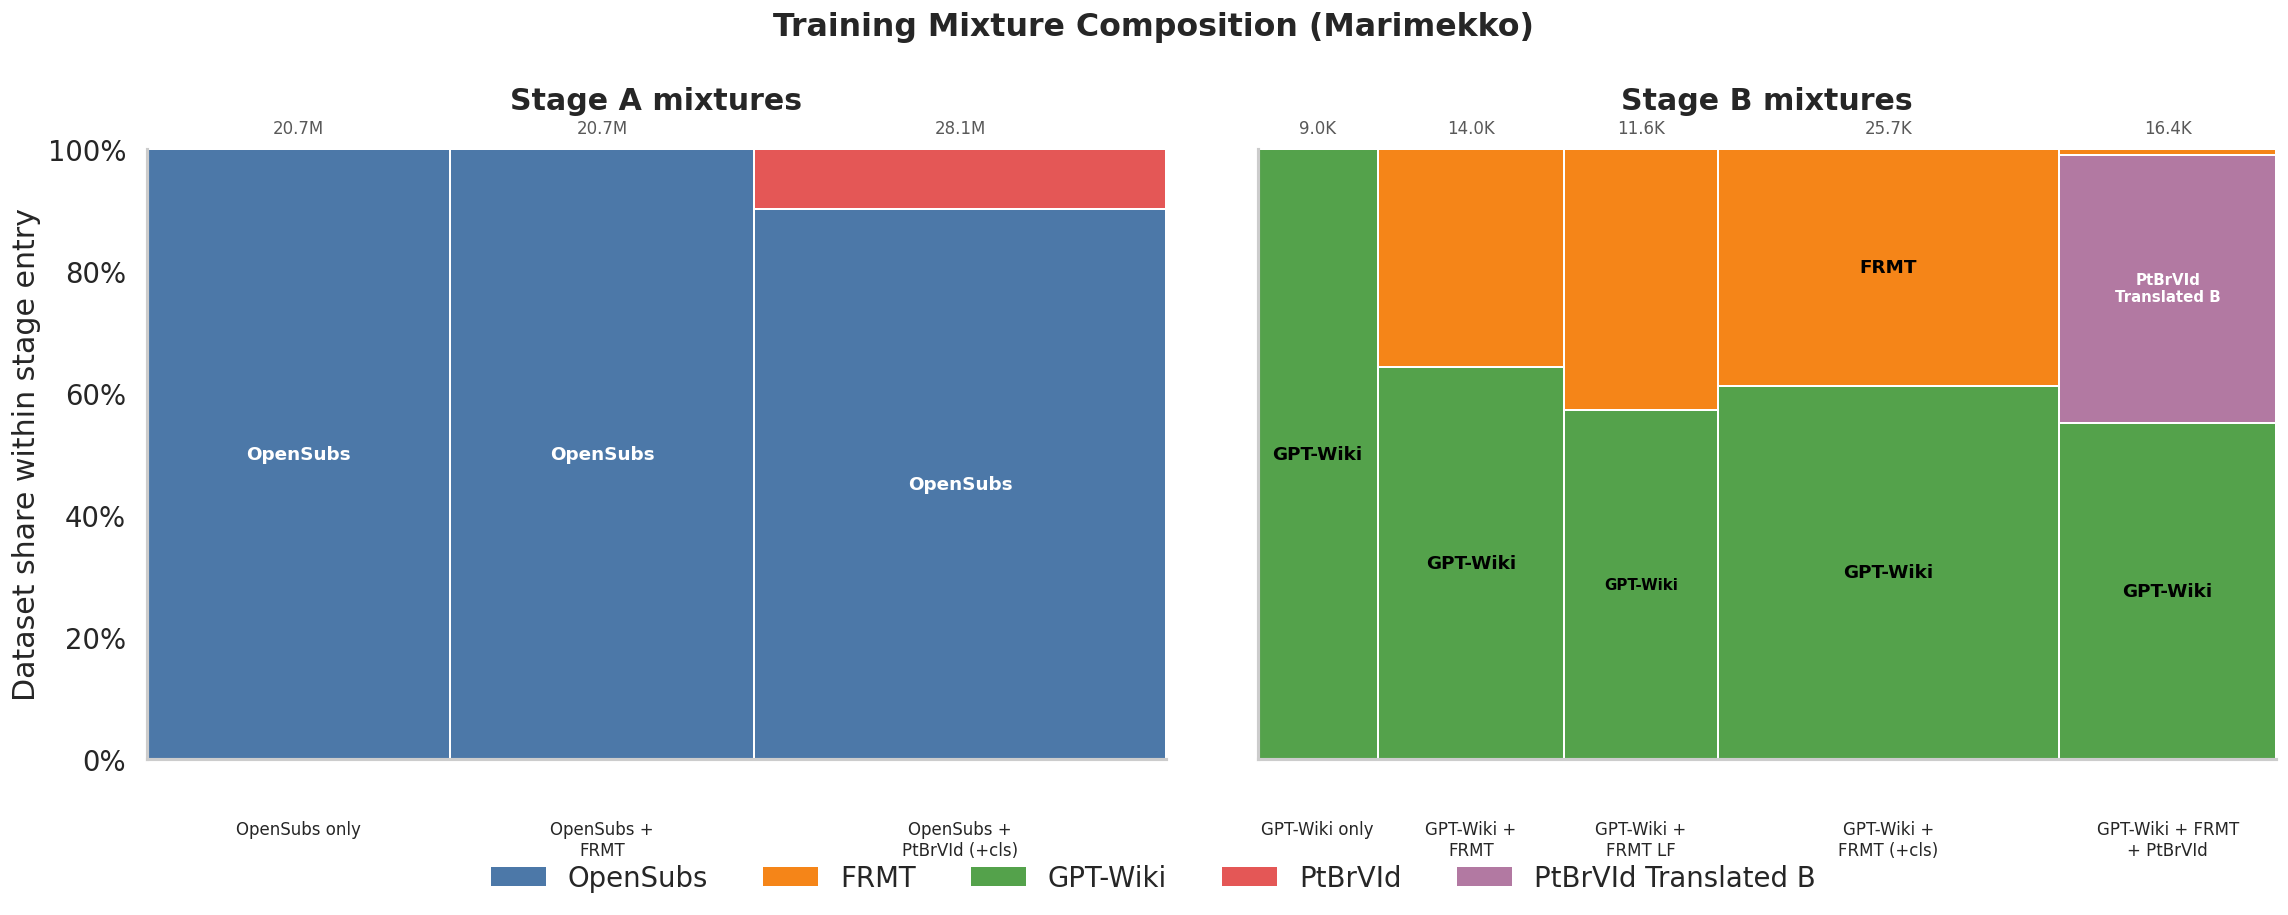

In [13]:
# 8) Marimekko training-mixture plot


def fmt_stage_rows(value):
    value = float(value)
    if value >= 1_000_000:
        return f"{value / 1_000_000:.1f}M"
    if value >= 1_000:
        return f"{value / 1_000:.1f}K"
    return f"{value:.0f}"


def draw_marimekko(ax, stage_entries, panel_title):
    part = prepare_stage_mix(stage_df, stage_entries, split="train").copy()
    part["dataset_plot"] = part["dataset"].replace({"GPT": "GPT-Wikipedia"})
    totals = part[["stage_entry", "total_rows"]].drop_duplicates().set_index("stage_entry")["total_rows"]
    grand_total = totals.sum()
    x0 = 0.0

    for stage_name in stage_entries:
        stage_part = part[part["stage_entry"].eq(stage_name)].copy()
        if stage_part.empty:
            continue
        width = totals.loc[stage_name] / grand_total
        y0 = 0.0
        for _, row in stage_part.sort_values("rows", ascending=False).iterrows():
            dataset_name = row["dataset_plot"]
            height = row["share"]
            rect = Rectangle(
                (x0, y0),
                width,
                height,
                facecolor=palette.get(dataset_name, "#BBBBBB"),
                edgecolor="white",
                linewidth=1.2,
            )
            ax.add_patch(rect)

            label = dataset_display_map.get(dataset_name, dataset_name)
            area = width * height
            if area > 0.07:
                rotation = 90 if width < 0.075 and height > 0.22 else 0
                text_color = "white" if dataset_name in {"OpenSubs", "PtBrVId", "PtBrVId-TranslatedStageB"} else "black"
                ax.text(
                    x0 + width / 2,
                    y0 + height / 2,
                    label,
                    ha="center",
                    va="center",
                    fontsize=9 if area < 0.11 else 11,
                    color=text_color,
                    weight="bold",
                    rotation=rotation,
                    clip_on=False,
                )
            y0 += height

        ax.text(
            x0 + width / 2,
            -0.10,
            stage_axis_label_map.get(stage_name, stage_name),
            ha="center",
            va="top",
            fontsize=10,
        )
        ax.text(
            x0 + width / 2,
            1.02,
            fmt_stage_rows(totals.loc[stage_name]),
            ha="center",
            va="bottom",
            fontsize=10,
            color="0.35",
        )
        x0 += width

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_title(panel_title, fontsize=18, fontweight="bold", pad=24)
    ax.grid(False)


fig, axes = plt.subplots(1, 2, figsize=(19.5, 8.2), sharey=True)
fig.subplots_adjust(left=0.07, right=0.98, top=0.84, bottom=0.22, wspace=0.09)

draw_marimekko(axes[0], stage_a_literal, "Stage A mixtures")
draw_marimekko(axes[1], stage_b_literal, "Stage B mixtures")
axes[0].set_ylabel("Dataset share within stage entry")
axes[1].set_ylabel("")

legend_labels = [
    dataset
    for dataset in ["OpenSubs", "FRMT", "GPT-Wikipedia", "PtBrVId", "PtBrVId-TranslatedStageB"]
    if dataset in set(stage_df["dataset_plot"])
]
legend_handles = [Rectangle((0, 0), 1, 1, facecolor=palette[dataset], edgecolor="none") for dataset in legend_labels]
legend_text = [dataset_display_map.get(dataset, dataset).replace("\n", " ") for dataset in legend_labels]
fig.legend(legend_handles, legend_text, loc="lower center", bbox_to_anchor=(0.5, 0.06), ncol=5, frameon=False)
fig.suptitle("Training Mixture Composition (Marimekko)", y=0.98, fontsize=19, fontweight="bold")

plt.show()


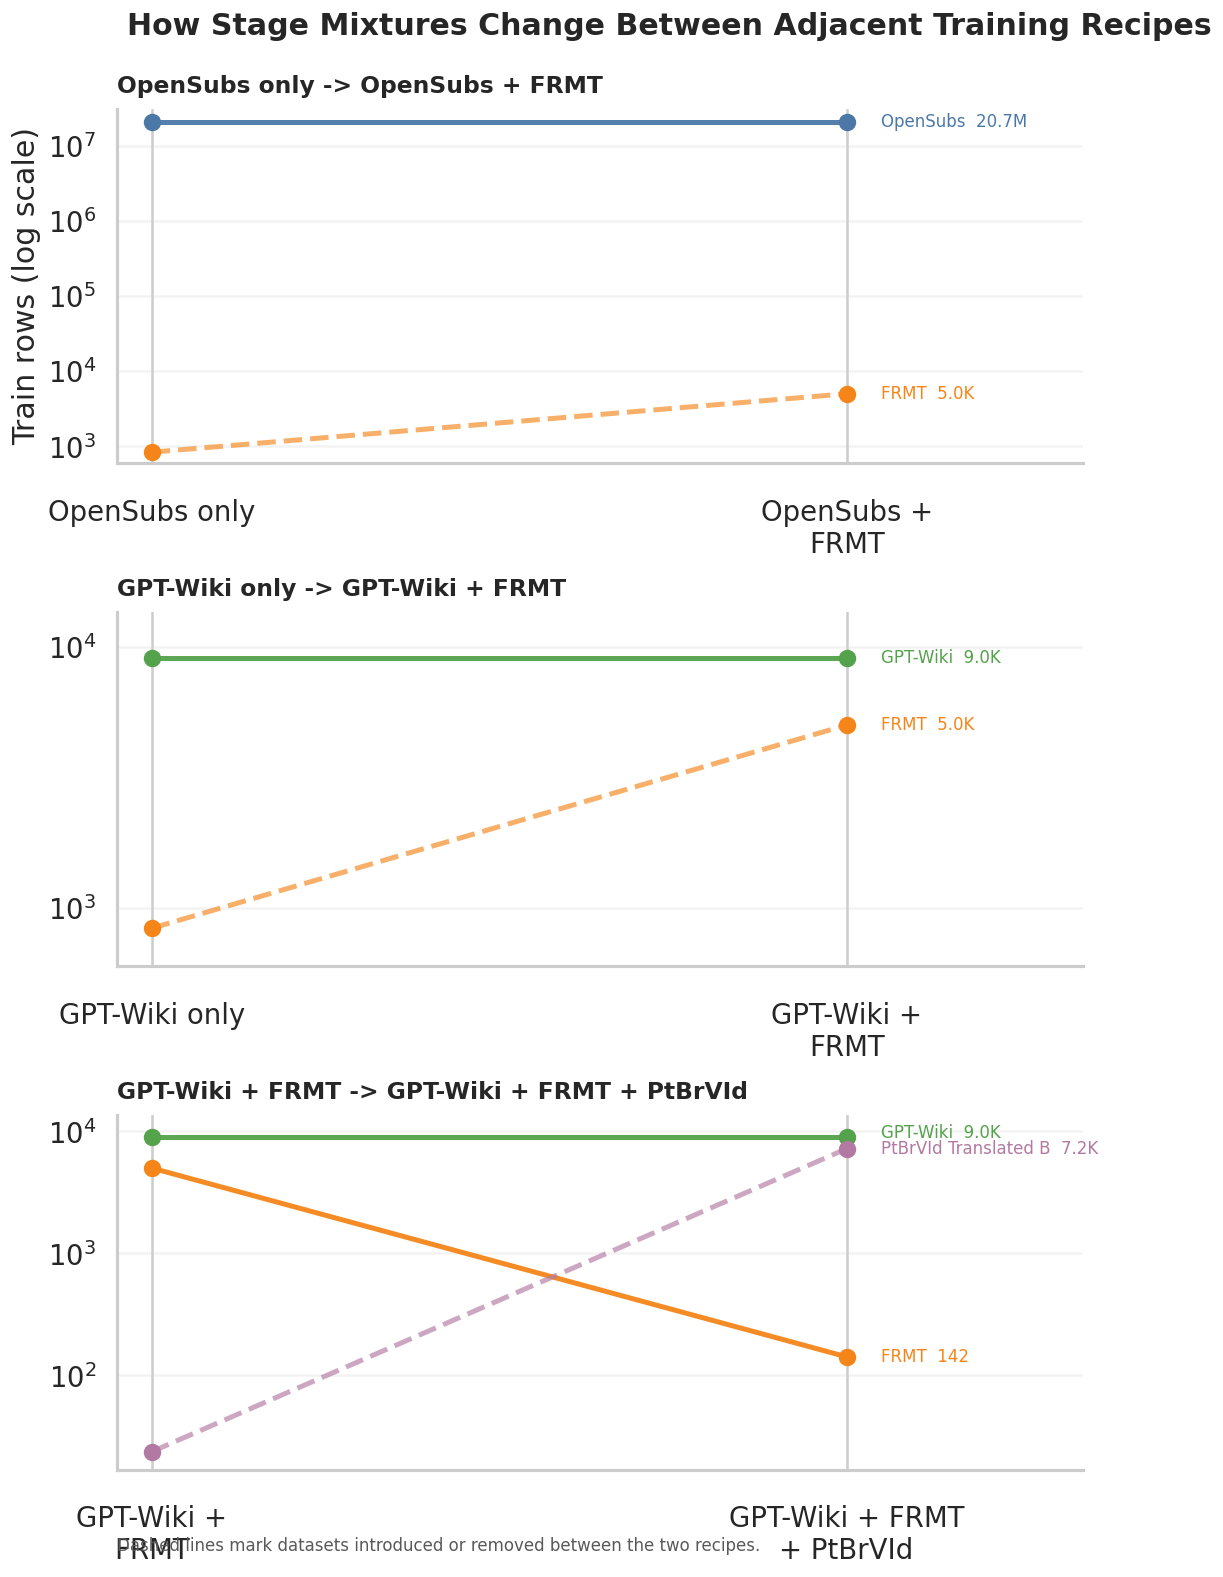

In [14]:
# 9) Slopegraph for stage-to-stage mixture changes

comparison_pairs = [
    ("stageA_opensubs_only_translation", "stageA_opensubs_frmt_translation"),
    ("stageB_gpt_wiki_translation", "stageB_gpt_wiki_frmt_mix_translation"),
    ("stageB_gpt_wiki_frmt_mix_translation", "stageB_gpt_wiki_frmt_mix_optional_ptbrvarid_translation"),
]


def fmt_stage_rows_short(value):
    value = float(value)
    if value >= 1_000_000:
        return f"{value / 1_000_000:.1f}M"
    if value >= 1_000:
        return f"{value / 1_000:.1f}K"
    return f"{value:.0f}"


def spread_log_positions(values, min_gap=0.12):
    if len(values) <= 1:
        return np.array(values, dtype=float)
    logs = np.log10(np.asarray(values, dtype=float))
    order = np.argsort(logs)
    adjusted = logs.copy()
    for pos in range(1, len(order)):
        prev_idx = order[pos - 1]
        curr_idx = order[pos]
        if adjusted[curr_idx] - adjusted[prev_idx] < min_gap:
            adjusted[curr_idx] = adjusted[prev_idx] + min_gap
    return 10 ** adjusted


fig, axes = plt.subplots(len(comparison_pairs), 1, figsize=(11.5, 13.5), sharex=False)
fig.subplots_adjust(left=0.10, right=0.80, top=0.92, bottom=0.08, hspace=0.42)
axes = np.atleast_1d(axes)

for panel_idx, (ax, (left_stage, right_stage)) in enumerate(zip(axes, comparison_pairs)):
    pair_df = prepare_stage_mix(stage_df, [left_stage, right_stage], split="train").copy()
    pair_df["dataset_plot"] = pair_df["dataset"].replace({"GPT": "GPT-Wikipedia"})
    pivot = (
        pair_df.pivot_table(index="dataset_plot", columns="stage_entry", values="rows", aggfunc="sum")
        .reindex(columns=[left_stage, right_stage])
        .fillna(0)
    )

    positive_values = pivot.to_numpy().ravel()
    positive_values = positive_values[positive_values > 0]
    if len(positive_values) == 0:
        continue

    floor = max(float(positive_values.min()) / 6, 1.0)
    ymax = max(float(positive_values.max()) * 1.5, floor * 12)
    right_items = []

    for dataset_name, row in pivot.iterrows():
        left_rows = float(row[left_stage])
        right_rows = float(row[right_stage])
        plot_left = left_rows if left_rows > 0 else floor
        plot_right = right_rows if right_rows > 0 else floor
        linestyle = "-" if left_rows > 0 and right_rows > 0 else "--"
        alpha = 0.95 if left_rows > 0 and right_rows > 0 else 0.65
        color = palette.get(dataset_name, "gray")

        ax.plot(
            [0, 1],
            [plot_left, plot_right],
            color=color,
            linewidth=3,
            linestyle=linestyle,
            alpha=alpha,
            zorder=2,
        )
        ax.scatter([0, 1], [plot_left, plot_right], color=color, s=80, zorder=3)

        right_items.append((dataset_name, right_rows, plot_right, color))

    right_items = sorted(right_items, key=lambda item: item[2])
    right_positions = spread_log_positions([item[2] for item in right_items], min_gap=0.13)

    for (dataset_name, raw_value, _plot_right, color), text_y in zip(right_items, right_positions):
        label_name = dataset_display_map.get(dataset_name, dataset_name).replace(chr(10), " ")
        label_value = fmt_stage_rows_short(raw_value) if raw_value > 0 else "0"
        ax.text(
            1.05,
            text_y,
            f"{label_name}  {label_value}",
            ha="left",
            va="center",
            fontsize=10,
            color=color,
            clip_on=False,
        )

    ax.set_xticks(
        [0, 1],
        [stage_axis_label_map.get(left_stage, left_stage), stage_axis_label_map.get(right_stage, right_stage)],
    )
    ax.set_xlim(-0.05, 1.34)
    ax.set_yscale("log")
    ax.set_ylim(floor / 1.4, ymax)
    ax.grid(axis="y", alpha=0.22)
    ax.tick_params(axis="x", pad=12)
    ax.set_title(
        f"{stage_label_map.get(left_stage, left_stage)} -> {stage_label_map.get(right_stage, right_stage)}",
        loc="left",
        fontsize=14,
        fontweight="bold",
        pad=10,
    )
    style_ax(ax, title=None, xlabel=None, ylabel="Train rows (log scale)" if panel_idx == 0 else None)

fig.suptitle("How Stage Mixtures Change Between Adjacent Training Recipes", y=0.98, fontsize=18, fontweight="bold")
fig.text(0.10, 0.03, "Dashed lines mark datasets introduced or removed between the two recipes.", fontsize=10, color="0.35")

plt.show()


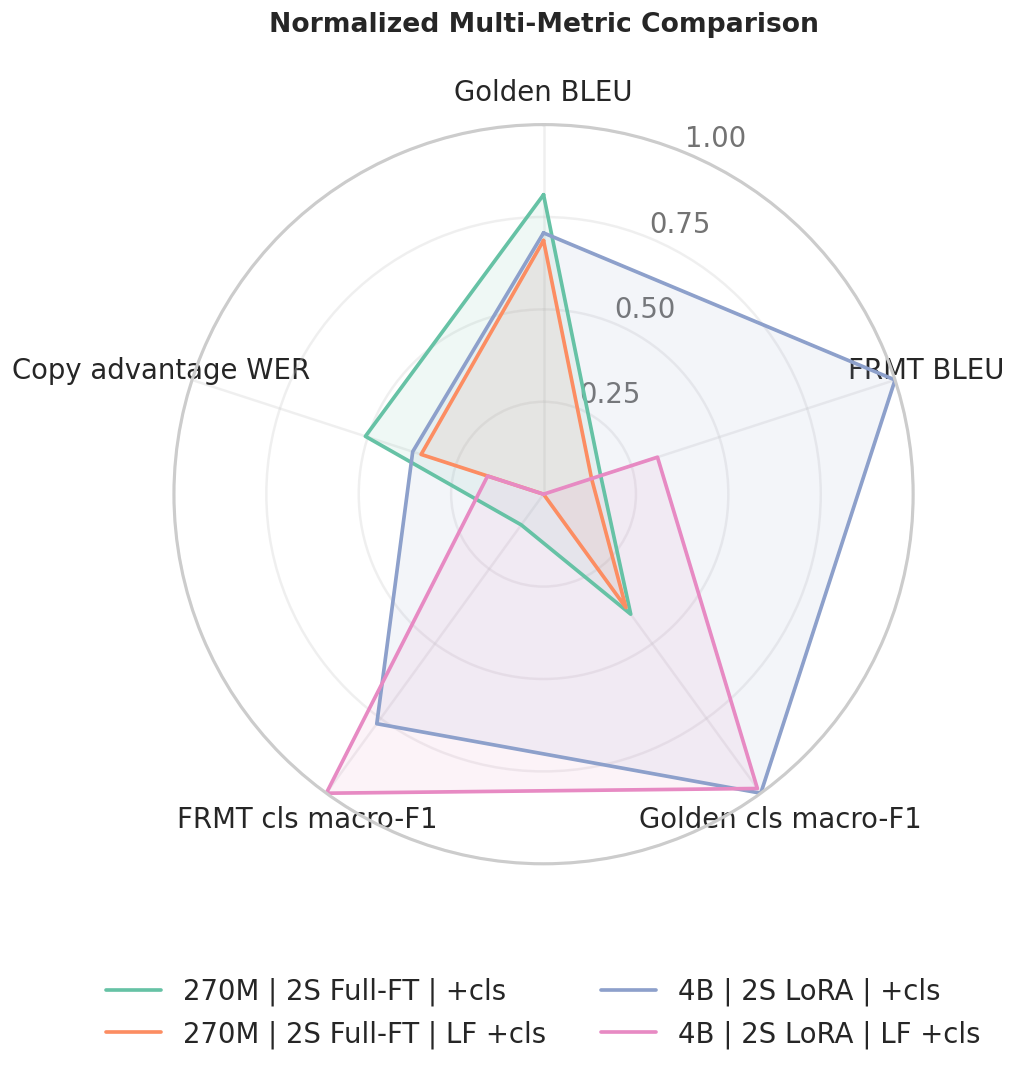

In [15]:
# 10) Radar chart

radar_df = rank_df.copy()
radar_df["gold_wer_inverted"] = 1 / (1 + pd.to_numeric(radar_df["gold_wer"], errors="coerce"))
radar_df["frmt_wer_inverted"] = 1 / (1 + pd.to_numeric(radar_df["frmt_wer"], errors="coerce"))

radar_metric_map = {
    "gold_bleu": ("Golden BLEU", True),
    "frmt_bleu": ("FRMT BLEU", True),
    "gold_cls_f1_macro": ("Golden cls macro-F1", True),
    "frmt_cls_f1_macro": ("FRMT cls macro-F1", True),
    "gold_copy_advantage_wer": ("Copy advantage WER", True),
}

for metric, (_, higher_is_better) in radar_metric_map.items():
    radar_df[metric] = pd.to_numeric(radar_df[metric], errors="coerce")
    radar_df[f"{metric}_norm"] = minmax_scale(radar_df[metric], higher_is_better=higher_is_better)

radar_candidates = radar_df.dropna(subset=list(radar_metric_map)).copy()
chosen = radar_candidates[
    radar_candidates["stage"].eq("stage_b")
    & radar_candidates["recipe"].eq("GPT-Wiki+FRMT")
    & radar_candidates["comparison_family"].isin(["two_staged_lora", "two_staged_fullft"])
    & radar_candidates["variant"].isin(["+cls", "label-first +cls"])
    & ~radar_candidates["ptbrvarid_stage_a"]
    & ~radar_candidates["uses_equal_rows"]
].copy()

if chosen.empty:
    chosen = radar_candidates.nlargest(4, "gold_bleu").copy()


def radar_label(row):
    family_short = {
        "two_staged_lora": "2S LoRA",
        "two_staged_fullft": "2S Full-FT",
        "stage_c_drgrpo": "Stage C GRPO",
    }
    variant_short = {
        "+cls": "+cls",
        "label-first +cls": "LF +cls",
    }
    pieces = [str(row["size"]), family_short.get(row["comparison_family"], str(row["comparison_family"])), variant_short.get(str(row["variant"]), str(row["variant"]))]
    return " | ".join(pieces)


chosen = chosen.sort_values(["size", "comparison_family", "variant"]).copy()
chosen["radar_label"] = chosen.apply(radar_label, axis=1)

categories = [f"{metric}_norm" for metric in radar_metric_map]
category_labels = [label for label, _ in radar_metric_map.values()]
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 8), subplot_kw={"polar": True})
palette_radar = sns.color_palette("Set2", n_colors=len(chosen))

for color, (_, row) in zip(palette_radar, chosen.iterrows()):
    values = row[categories].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2.2, label=row["radar_label"], color=color)
    ax.fill(angles, values, alpha=0.10, color=color)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(category_labels)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"], color="0.45")
ax.grid(alpha=0.30)
ax.set_title("Normalized Multi-Metric Comparison", pad=28, fontsize=16, fontweight="bold")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)

plt.show()


,label,path,accuracy,macro_f1,n
0,4B | +cls,eval_results/encoder_decoder/compare_staged/go...,0.695971,0.463367,546
1,4B | LF +cls,eval_results/encoder_decoder/compare_staged/go...,0.695971,0.462532,546
2,270M | +cls,eval_results/encoder_decoder/compare_staged/go...,0.650183,0.431714,546
3,270M | LF +cls,eval_results/encoder_decoder/compare_staged/go...,0.648352,0.430559,546


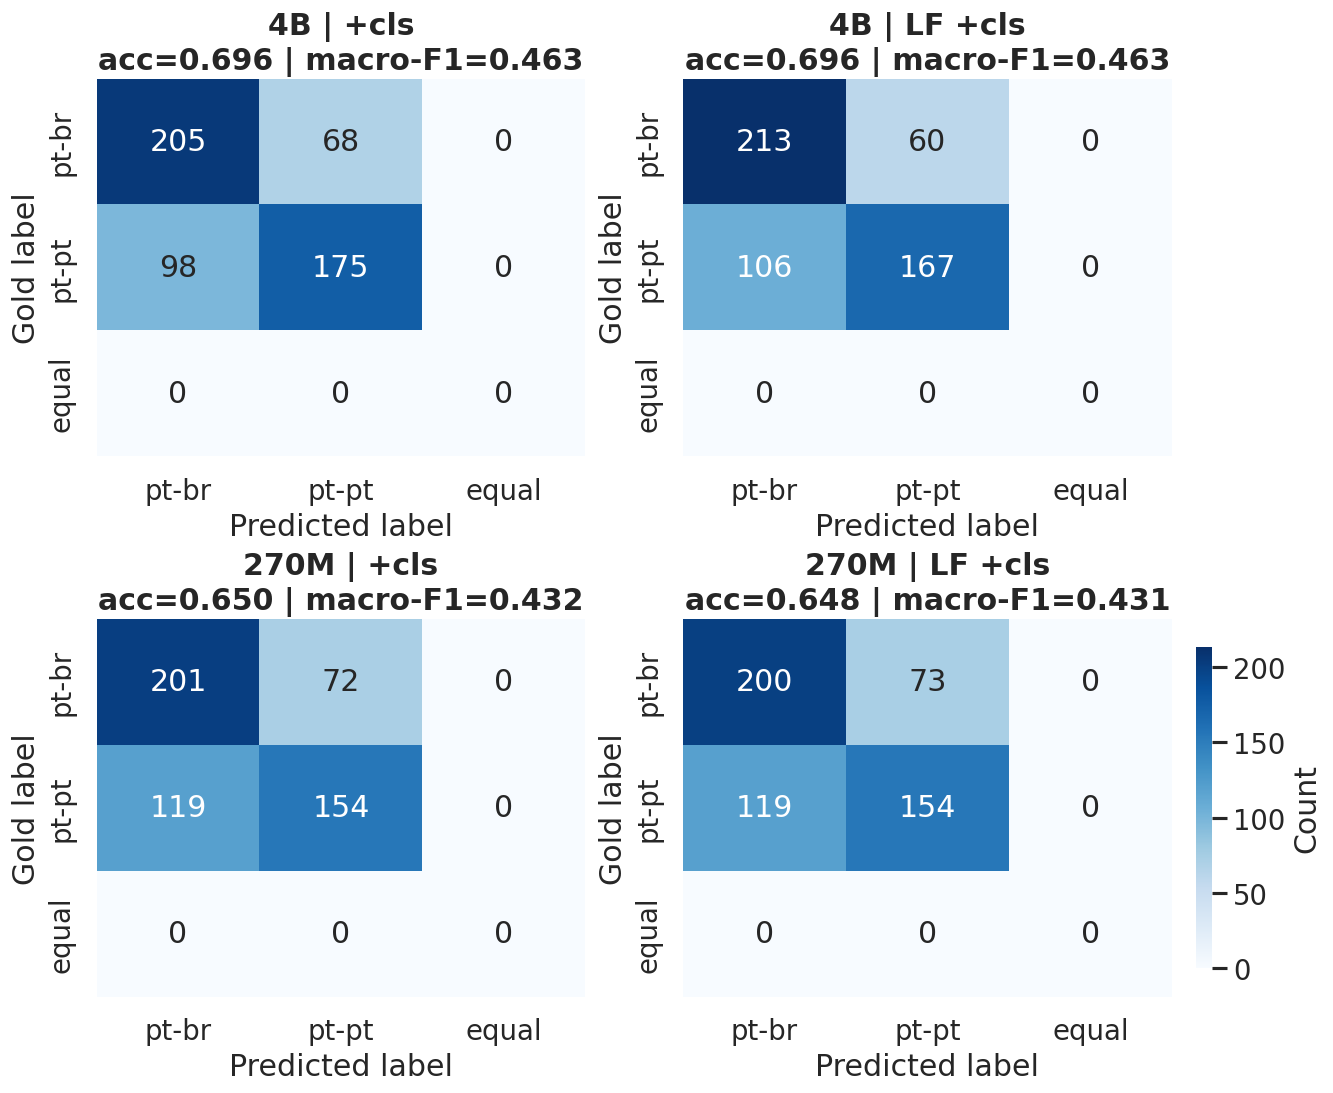

In [16]:
# 11) Classification summaries and confusion matrices

cls_summary_paths = sorted((EVAL_DIR / "compare_staged" / "golden_collection").glob("**/*classification_summary.json"))

summary_selection = [
    ("4B | +cls", "t5gemma2_4b_classification_r48_stageB_gpt_wiki_frmt_with_cls"),
    ("4B | LF +cls", "t5gemma2_4b_classification_r48_stageB_gpt_wiki_frmt_label_first_with_cls"),
    ("270M | +cls", "t5gemma2_270m_classification_stageB_gpt_wiki_frmt_with_cls"),
    ("270M | LF +cls", "t5gemma2_270m_classification_stageB_gpt_wiki_frmt_label_first_with_cls"),
]

selected_summaries = []
for label, pattern in summary_selection:
    match = next((path for path in cls_summary_paths if pattern in str(path)), None)
    if match is None:
        continue
    summary = load_json(match)
    labels = list((summary.get("per_class") or {}).keys()) or ["pt-br", "pt-pt", "equal"]
    cm_df = confusion_dict_to_df(summary["confusion_matrix"], labels=labels)
    selected_summaries.append(
        {
            "label": label,
            "path": str(match.relative_to(REPO_ROOT)),
            "accuracy": summary.get("accuracy"),
            "macro_f1": summary.get("macro_f1"),
            "n": summary.get("n"),
            "cm_df": cm_df,
        }
    )

summary_table = pd.DataFrame(
    [
        {k: v for k, v in item.items() if k != "cm_df"}
        for item in selected_summaries
    ]
)
display(summary_table)

vmax = max(int(item["cm_df"].to_numpy().max()) for item in selected_summaries)
fig, axes = plt.subplots(2, 2, figsize=(11, 9), constrained_layout=True)

for ax, item in zip(axes.flat, selected_summaries):
    sns.heatmap(
        item["cm_df"],
        annot=True,
        fmt="d",
        cmap="Blues",
        vmin=0,
        vmax=vmax,
        cbar=ax is axes.flat[-1],
        cbar_kws={"shrink": 0.85, "label": "Count"},
        ax=ax,
    )
    ax.set_title(f"{item['label']}\nacc={item['accuracy']:.3f} | macro-F1={item['macro_f1']:.3f}")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("Gold label")

plt.show()


In [17]:
# 12) Qualitative examples from prediction files

import re
from difflib import SequenceMatcher

pd.set_option("display.max_colwidth", 140)

QUAL_MAIN_MODEL = "4B Two-Staged LoRA r48 - Golden Collection (GPT-Wiki Stage B)"
QUAL_LABEL_FIRST_MODEL = "4B Two-Staged LoRA r48 - Golden Collection (GPT-Wiki+FRMT Stage B label-first translation-only)"


def strip_task_prefix(text):
    text = re.sub(r"^<[^>]+>\s*", "", str(text)).strip()
    text = re.sub(r"^(BR|PT|EQUAL)\s+", "", text).strip()
    return text


def word_wer(reference, hypothesis):
    ref_tokens = str(reference).split()
    hyp_tokens = str(hypothesis).split()
    if not ref_tokens:
        return 0.0 if not hyp_tokens else 1.0

    dp = [[0] * (len(hyp_tokens) + 1) for _ in range(len(ref_tokens) + 1)]
    for i in range(len(ref_tokens) + 1):
        dp[i][0] = i
    for j in range(len(hyp_tokens) + 1):
        dp[0][j] = j

    for i in range(1, len(ref_tokens) + 1):
        for j in range(1, len(hyp_tokens) + 1):
            cost = 0 if ref_tokens[i - 1] == hyp_tokens[j - 1] else 1
            dp[i][j] = min(
                dp[i - 1][j] + 1,
                dp[i][j - 1] + 1,
                dp[i - 1][j - 1] + cost,
            )

    return dp[-1][-1] / len(ref_tokens)


def load_predictions_from_report(report_df, model_name):
    pred_rel = report_df.loc[report_df["model"].eq(model_name), "predictions_path"].iloc[0]
    pred_path = REPO_ROOT / pred_rel
    pred_df = pd.read_json(pred_path, lines=True)
    pred_df["source_text"] = pred_df["input_text"].map(strip_task_prefix)
    pred_df["gold_text"] = pred_df["gold"].map(str)
    pred_df["pred_text"] = pred_df["pred_raw"].map(str)
    pred_df["copy_baseline"] = pred_df["source_text"]
    pred_df["model_wer"] = pred_df.apply(lambda row: word_wer(row["gold_text"], row["pred_text"]), axis=1)
    pred_df["copy_wer"] = pred_df.apply(lambda row: word_wer(row["gold_text"], row["copy_baseline"]), axis=1)
    pred_df["wer_gain_vs_copy"] = pred_df["copy_wer"] - pred_df["model_wer"]
    pred_df["source_pred_similarity"] = pred_df.apply(
        lambda row: SequenceMatcher(None, row["source_text"], row["pred_text"]).ratio(), axis=1
    )
    return pred_df


qual_main = load_predictions_from_report(gold_trans, QUAL_MAIN_MODEL)
qual_label_first = load_predictions_from_report(gold_trans, QUAL_LABEL_FIRST_MODEL)

best_model_wins = qual_main.sort_values("wer_gain_vs_copy", ascending=False).head(5)
copy_wins = qual_main.sort_values("wer_gain_vs_copy", ascending=True).head(5)
near_copy = qual_main[qual_main["source_pred_similarity"] >= 0.97].sort_values("model_wer", ascending=False).head(5)
rewrite_heavy = qual_main[qual_main["source_pred_similarity"] <= 0.75].sort_values("wer_gain_vs_copy", ascending=False).head(5)

qual_cols = [
    "source_text",
    "gold_text",
    "pred_text",
    "copy_baseline",
    "model_wer",
    "copy_wer",
    "wer_gain_vs_copy",
]

display(best_model_wins[qual_cols])
display(copy_wins[qual_cols])
display(near_copy[qual_cols])
display(rewrite_heavy[qual_cols])

if {"gold_source_variant_norm", "pred_source_variant_norm"}.issubset(qual_label_first.columns):
    qual_label_first["label_match"] = (
        qual_label_first["gold_source_variant_norm"].astype(str).str.lower()
        == qual_label_first["pred_source_variant_norm"].astype(str).str.lower()
    )
    label_first_pathologies = qual_label_first[
        qual_label_first["label_match"]
        & qual_label_first["model_wer"].ge(qual_label_first["model_wer"].quantile(0.85))
    ].sort_values("model_wer", ascending=False).head(5)

    display(
        label_first_pathologies[
            [
                "source_text",
                "gold_text",
                "pred_text",
                "gold_source_variant_norm",
                "pred_source_variant_norm",
                "model_wer",
                "copy_wer",
            ]
        ]
    )


,source_text,gold_text,pred_text,copy_baseline,model_wer,copy_wer,wer_gain_vs_copy
609,Comenta e vota que gostaste.,Comente e vote se gostou.,Comente e vote que gostou.,Comenta e vota que gostaste.,0.200000,0.800000,0.6
735,Tu tens sérios problemas.,Você tem serios problemas.,Você tem sérios problemas.,Tu tens sérios problemas.,0.250000,0.750000,0.5
775,- Estou a mentir.,- Minto.,Estou mentindo.,- Estou a mentir.,1.000000,1.500000,0.5
706,"ー Você não esta cooperando, porra.","ー Não estás a cooperar, porra.","Não estás a cooperar, porra.","ー Você não esta cooperando, porra.",0.166667,0.666667,0.5
548,está famoso!,Está famoso!,Está famoso!,está famoso!,0.000000,0.500000,0.5


,source_text,gold_text,pred_text,copy_baseline,model_wer,copy_wer,wer_gain_vs_copy
638,- Eu não acredito nisso !!,- Eu não acredito nisso !!,Não acredito nisso!,- Eu não acredito nisso !!,0.833333,0.00,-0.833333
427,— Mãe-pretinha!,— Mãe-pretinha!,Mãe-pretinha!,— Mãe-pretinha!,0.500000,0.00,-0.500000
771,"Duas,quatro, oito e então..","Duas,quatro, oito e então...","Duas, quatro, oito e então..","Duas,quatro, oito e então..",0.750000,0.25,-0.500000
770,"Duas,quatro, oito e então...","Duas,quatro, oito e então..","Duas, quatro, oito e então...","Duas,quatro, oito e então...",0.750000,0.25,-0.500000
492,"— Não, que lembrança!","— Não, que lembrança!","Não, que memória!","— Não, que lembrança!",0.500000,0.00,-0.500000


,source_text,gold_text,pred_text,copy_baseline,model_wer,copy_wer,wer_gain_vs_copy
671,- Ela diz.,-ela fala.,- Ela diz.,- Ela diz.,1.500000,1.500000,0.0
665,"Olhou para o vovô, que se riu.",Olho veio para vovô que dá risada.,"Olhou para o vovô, que se riu.","Olhou para o vovô, que se riu.",0.857143,0.857143,0.0
664,Olho veio para vovô que dá risada.,"Olhou para o vovô, que se riu.",Olho veio para vovô que dá risada.,Olho veio para vovô que dá risada.,0.857143,0.857143,0.0
410,"disse Raimundo consigo, respirando.","Disse Raimundo para si mesmo, a respirar.","disse Raimundo consigo, respirando.","disse Raimundo consigo, respirando.",0.857143,0.857143,0.0
799,"É só para me respeitares, pequena menina.",E so para me respeita garotinha.,"É só para me respeitar, pequena menina.","É só para me respeitares, pequena menina.",0.833333,0.833333,0.0


,source_text,gold_text,pred_text,copy_baseline,model_wer,copy_wer,wer_gain_vs_copy
706,"ー Você não esta cooperando, porra.","ー Não estás a cooperar, porra.","Não estás a cooperar, porra.","ー Você não esta cooperando, porra.",0.166667,0.666667,0.500
775,- Estou a mentir.,- Minto.,Estou mentindo.,- Estou a mentir.,1.000000,1.500000,0.500
734,Você tem serios problemas.,Tu tens sérios problemas.,Tens sérios problemas.,Você tem serios problemas.,0.500000,0.750000,0.250
289,"Não é admissível que, ao resolver um problema dessa envergadura, com todos os factos que o envolvem, a Assembleia Nacional Constituinte,...","Não é admissível que, ao resolver um problema dessa envergadura, com todos os fatos que o envolvem, a Assembléia Nacional Constituinte, ...","Não é admissível que, ao resolver um problema dessa envergadura, com todos os fatos que o envolvem, a Assembleia Nacional Constituinte, ...","Não é admissível que, ao resolver um problema dessa envergadura, com todos os factos que o envolvem, a Assembleia Nacional Constituinte,...",0.025000,0.050000,0.025
681,Vieste para ficar?,veio pra ficar?,Você veio para ficar?,Vieste para ficar?,0.666667,0.666667,0.000


,source_text,gold_text,pred_text,gold_source_variant_norm,pred_source_variant_norm,model_wer,copy_wer
396,- Oww você é um amor Obrigado viu!- Falei e o mesmo retribuiu com um abraço.,"Oww, és adorável. Obrigado!","Oww tu és um amor, obrigada! - Digo e ele retribui com um abraço.",pt-br,pt-br,3.25,4.0
435,- Estou a mentir.,Minto.,Estou mentindo.,pt-pt,pt-pt,2.00,4.0
308,Comente e vote se gostou.,Comenta e vota que gostaste.,Deixe um comentário e vote se gostou.,pt-br,pt-br,1.20,0.8
241,"Meu menino, deixemo-nos de disparates!","Meu menino, deixemo-nos de patacoadas!","Meu filho, pare com essas besteiras!",pt-pt,pt-pt,1.00,0.2
273,Foi feliz..,Foi feliz...,Ele foi feliz...,pt-pt,pt-pt,1.00,0.5


## Suggested Next Steps

1. Finish the PtBrVId preprocessing figures first. They are already supported by clean CSVs.
2. Curate a small model subset before implementing the rank, scatter, and radar plots.
3. Split the training-mixture visuals into Stage A and Stage B panels if one combined figure gets too dense.
4. Keep the radar plot as a summary figure, not the primary evidence figure.
5. Once the exploratory versions look right, add `savefig(...)` calls only for the thesis-ready variants.
